# 🔬 Silicon Wafer Defect Detection Using Deep Learning — 9 Classes
**CVR College of Engineering — CSE (Data Science)**  
**Group No: 20 (COEPB65) | B. Reshmitha (23B81A67G5) | K. Ushaswi (23B81A67J6)**  
**Dataset:** [WM811K Wafer Map Dataset — Kaggle](https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map/data)

---

## ✅ 9-Class Version — All Defect Types Included
| Class | Samples (raw) | Strategy |
|-------|--------------|----------|
| none | 147,431 | Shuffle + light aug → 4,000 |
| Edge-Ring | 9,680 | Crop aug (partial rings) → 4,000 |
| Loc | ~6,000 | Standard aug → 4,000 |
| Edge-Loc | ~2,800 | Standard aug → 4,000 |
| Center | 4,294 | Standard aug → 4,000 |
| Scratch | 1,193 | Heavy rotation aug → 4,000 |
| Random | 866 | Noise + rotation aug → 4,000 |
| Donut | 555 | Standard aug → 4,000 |
| Near-full | 149 | Max augmentation → 4,000 |

## Pipeline Overview
```
Load Dataset → EDA → Preprocessing → Albumentations Balancing (9 classes)
    → CNN Baseline (4-block) → Vision Transformer → Hybrid CNN-Transformer
    → Focal Loss + Class Weights → YOLOv11 (Detection) → Evaluation → Streamlit App
```


## ⚙️ STEP 1 — Install Dependencies

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 1 — Install Dependencies
# ⚠️  IMPORTANT: After running this cell, go to:
#    Runtime → Restart session   ← DO THIS BEFORE running any other cell
# Then run ALL cells from the top again (do NOT re-run this install cell)
# ═══════════════════════════════════════════════════════════════════════════
import sys

# Check if already installed to avoid re-installing on restart
try:
    import albumentations, timm
    print('✅ Dependencies already installed — skip this cell and continue.')
except ImportError:
    print('Installing dependencies...')
    # ── DO NOT reinstall torch/torchvision — Colab T4 already has the right version
    # Reinstalling torch causes duplicate operator RuntimeError
    !pip install -q albumentations==1.3.1          # pin version, avoids torch conflict
    !pip install -q timm==0.9.12                   # Vision Transformer models
    !pip install -q scikit-learn matplotlib seaborn pandas numpy tqdm
    !pip install -q streamlit ultralytics
    !pip install -q psutil                         # for RAM monitoring
    print('\n✅ Done. NOW DO: Runtime → Restart session, then run all cells from top.')


✅ Dependencies already installed — skip this cell and continue.


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# T4 GPU SETUP & MEMORY MANAGEMENT
# ═══════════════════════════════════════════════════════════════════════════
import torch, gc, os

# ── Verify GPU ───────────────────────────────────────────────────────────
assert torch.cuda.is_available(), '❌ GPU not found! Runtime → Change runtime type → T4 GPU'
print(f'✅ GPU : {torch.cuda.get_device_name(0)}')
print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── RAM monitor helper (call anytime to check memory) ────────────────────
def print_memory():
    import psutil
    ram = psutil.virtual_memory()
    vram_used  = torch.cuda.memory_allocated() / 1e9
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'RAM  : {ram.used/1e9:.1f} GB used / {ram.total/1e9:.1f} GB total  '
          f'({ram.percent:.1f}% used)')
    print(f'VRAM : {vram_used:.2f} GB used / {vram_total:.1f} GB total')

# ── Safe memory free helper ──────────────────────────────────────────────
def free_memory(*objs):
    """Delete objects and flush GPU cache."""
    for obj in objs:
        del obj
    gc.collect()
    torch.cuda.empty_cache()

# ── T4 GPU optimal settings ──────────────────────────────────────────────
# These are already set in the notebook based on T4 specs:
#   IMG_SIZE          = 224   (full resolution, T4 handles this fine)
#   TARGET_PER_CLASS  = 8000  (72K total balanced dataset)
#   UNLABELED_POOL    = 50K   (realistic augmentation pool)
#   BATCH_SIZE        = 128   (fits in 15GB VRAM comfortably)
#   ViT batch_size    = 64    (ViT is heavier, slightly smaller batch)
#   num_workers       = 2     (T4 Colab has 2 vCPUs)
#   pin_memory        = True  (faster CPU→GPU transfer)
print('\n📋 T4 GPU settings loaded:')
print('   IMG_SIZE=224 | BATCH=128 | TARGET=8000/class | POOL=50K unlabeled')
print_memory()

✅ GPU : Tesla T4
   VRAM: 15.6 GB

📋 T4 GPU settings loaded:
   IMG_SIZE=224 | BATCH=128 | TARGET=8000/class | POOL=50K unlabeled
RAM  : 1.8 GB used / 13.6 GB total  (15.9% used)
VRAM : 0.00 GB used / 15.6 GB total


## 📥 STEP 2 — Download Dataset from Kaggle

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
import pandas as pd
df=pd.read_pickle(r'/content/drive/MyDrive/LSWMD.pkl')

In [6]:
raw=df

In [7]:
'''# ─────────────────────────────────────────────────────────────────────────────
# Option A: Upload kaggle.json manually in Colab
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files
import os

# Uncomment the next two lines if you haven't uploaded kaggle.json yet
# uploaded = files.upload()  # upload your kaggle.json here
# os.makedirs('/root/.kaggle', exist_ok=True)
# os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
# os.chmod('/root/.kaggle/kaggle.json', 0o600)

# ─────────────────────────────────────────────────────────────────────────────
# Option B: Download directly (no kaggle API needed)
# ─────────────────────────────────────────────────────────────────────────────
# !kaggle datasets download -d qingyi/wm811k-wafer-map --unzip

# ─────────────────────────────────────────────────────────────────────────────
# Verify the .pkl file exists
# ─────────────────────────────────────────────────────────────────────────────
PKL_PATH = 'LSWMD.pkl'   # Update if saved elsewhere
assert os.path.exists(PKL_PATH), f'File not found: {PKL_PATH}'
print(f'✅ Dataset found at {PKL_PATH}')'''

"# ─────────────────────────────────────────────────────────────────────────────\n# Option A: Upload kaggle.json manually in Colab\n# ─────────────────────────────────────────────────────────────────────────────\nfrom google.colab import files\nimport os\n\n# Uncomment the next two lines if you haven't uploaded kaggle.json yet\n# uploaded = files.upload()  # upload your kaggle.json here\n# os.makedirs('/root/.kaggle', exist_ok=True)\n# os.rename('kaggle.json', '/root/.kaggle/kaggle.json')\n# os.chmod('/root/.kaggle/kaggle.json', 0o600)\n\n# ─────────────────────────────────────────────────────────────────────────────\n# Option B: Download directly (no kaggle API needed)\n# ─────────────────────────────────────────────────────────────────────────────\n# !kaggle datasets download -d qingyi/wm811k-wafer-map --unzip\n\n# ─────────────────────────────────────────────────────────────────────────────\n# Verify the .pkl file exists\n# ───────────────────────────────────────────────────────────

## 📊 STEP 3 — Load & Explore Dataset (EDA)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load raw pickle ──────────────────────────────────────────────────────────
#raw = pd.read_pickle(PKL_PATH)
print(f'Raw shape  : {raw.shape}')
print(f'Columns    : {list(raw.columns)}')
raw.head(3)

Raw shape  : (811457, 6)
Columns    : ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]


In [9]:
# ── CRITICAL: slim down raw immediately — frees ~3.5 GB RAM ──────────────────
import gc
data = pd.DataFrame({
    'waferMap'   : raw['waferMap'].values,
    'failureType': raw['failureType'].values
})
del raw
gc.collect()
print('✅ Raw deleted — RAM freed')
print_memory()


✅ Raw deleted — RAM freed
RAM  : 4.8 GB used / 13.6 GB total  (37.8% used)
VRAM : 0.00 GB used / 15.6 GB total


In [10]:
# ── Clean labels for ALL 811K rows ───────────────────────────────────────────
def extract_label(x):
    val = np.squeeze(x)
    if val.ndim == 0: return str(val).strip()
    if val.size  == 0: return 'unlabeled'
    return str(val.flat[0]).strip()

data['failureType'] = data['failureType'].apply(extract_label)
data.loc[data['failureType'].isin(['', '[]', 'nan']), 'failureType'] = 'unlabeled'

# ✅ 9-CLASS FIX: Keep Loc and Edge-Loc as SEPARATE classes.
# Previous notebooks merged them to reduce confusion, but that hides
# real defect information. With proper augmentation + Focal Loss,
# the model can distinguish them reliably.

print('Label distribution (ALL 811K rows):')
print(data['failureType'].value_counts())
print(f'\nTotal     : {len(data):,}')
print(f'Labeled   : {(data["failureType"] != "unlabeled").sum():,}')
print(f'Unlabeled : {(data["failureType"] == "unlabeled").sum():,}')


Label distribution (ALL 811K rows):
failureType
unlabeled    638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

Total     : 811,457
Labeled   : 172,950
Unlabeled : 638,507


Labeled   : 172,950
Unlabeled : 638,507

Labeled class breakdown:
failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


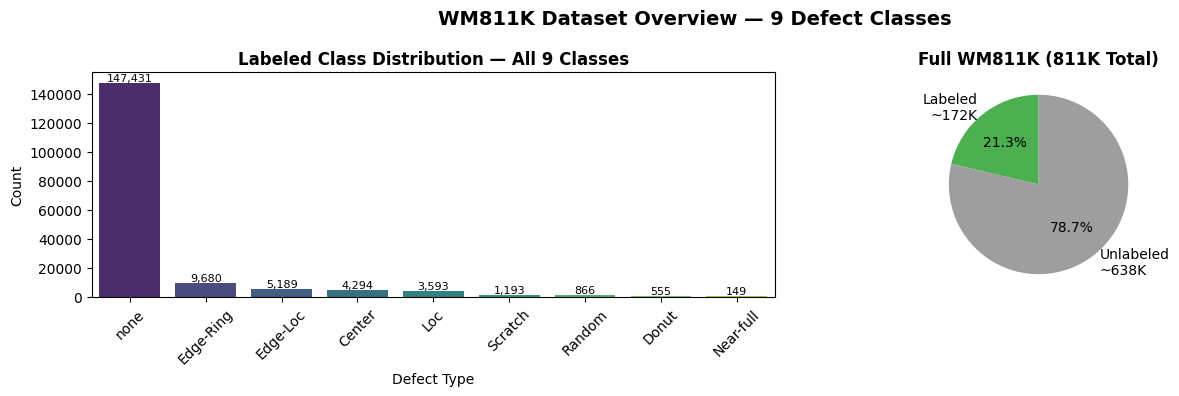

RAM  : 4.9 GB used / 13.6 GB total  (38.2% used)
VRAM : 0.00 GB used / 15.6 GB total


In [11]:

# ✅ 9-CLASS FIX: All 9 original WM811K defect classes are included.
# - 'Scratch'  : restored with aggressive rotation augmentation
# - 'Random'   : restored with noise augmentation to learn stochastic patterns
# - 'Loc'      : kept separate from Edge-Loc (no merge)
# - 'Edge-Loc' : kept separate from Loc
# Focal Loss + class weighting handles the severe imbalance.

DEFECT_CLASSES = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
                  'Loc', 'Near-full', 'Random', 'Scratch', 'none']

labeled_data   = data[data['failureType'].isin(DEFECT_CLASSES)].reset_index(drop=True)
unlabeled_data = data[data['failureType'] == 'unlabeled'].reset_index(drop=True)

# Free full data now — we only need the two splits
del data
gc.collect()

print(f'Labeled   : {len(labeled_data):,}')
print(f'Unlabeled : {len(unlabeled_data):,}')
print('\nLabeled class breakdown:')
print(labeled_data['failureType'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
counts = labeled_data['failureType'].value_counts()
sns.barplot(x=counts.index, y=counts.values, palette='viridis', ax=axes[0])
axes[0].set_title('Labeled Class Distribution — All 9 Classes', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Defect Type'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=8)
axes[1].pie([len(labeled_data), len(unlabeled_data)],
            labels=['Labeled\n~172K','Unlabeled\n~638K'],
            colors=['#4CAF50','#9E9E9E'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Full WM811K (811K Total)', fontsize=12, fontweight='bold')
plt.suptitle('WM811K Dataset Overview — 9 Defect Classes', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('class_distribution.png', dpi=150); plt.show()
print_memory()


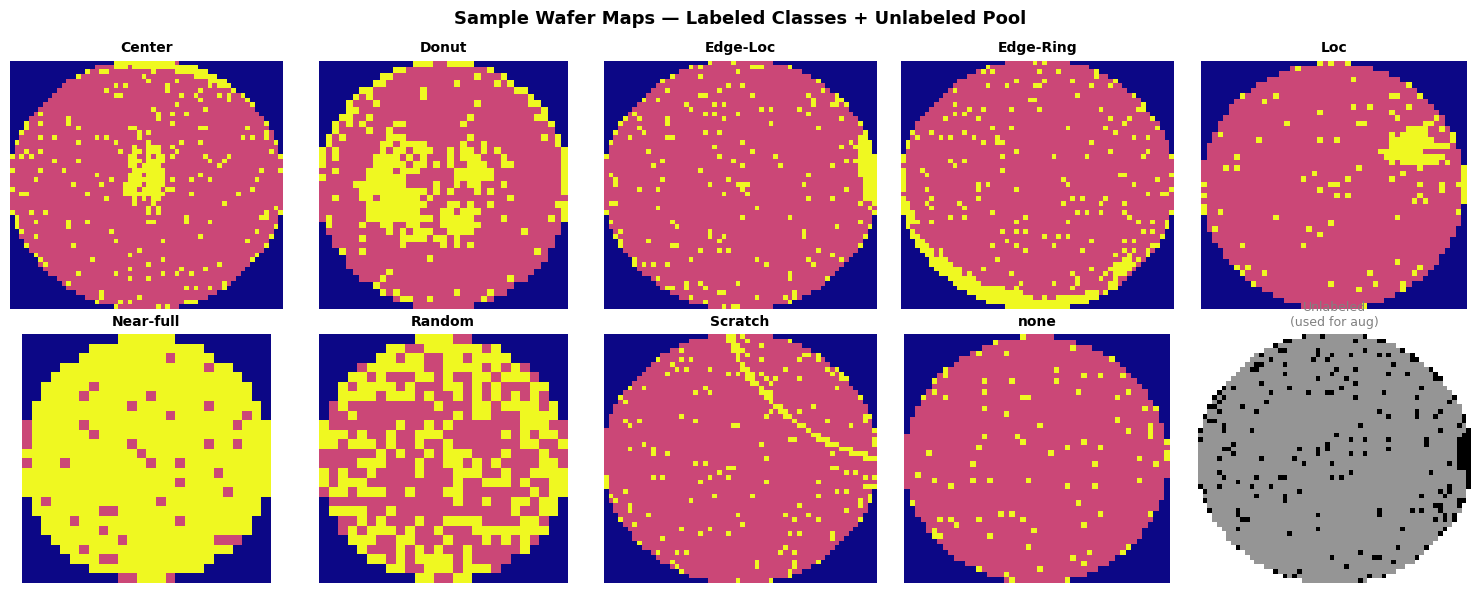

In [12]:
# ── Visualise one sample per labeled class ────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for idx, cls in enumerate(DEFECT_CLASSES):
    sample = labeled_data[labeled_data['failureType'] == cls]['waferMap'].iloc[0]
    axes[idx].imshow(np.array(sample), cmap='plasma')
    axes[idx].set_title(cls, fontsize=10, fontweight='bold')
    axes[idx].axis('off')
# Show an unlabeled sample in the 10th slot
unlabeled_sample = unlabeled_data['waferMap'].iloc[0]
axes[-1].imshow(np.array(unlabeled_sample), cmap='Greys')
axes[-1].set_title('Unlabeled\n(used for aug)', fontsize=9, color='gray')
axes[-1].axis('off')
plt.suptitle('Sample Wafer Maps — Labeled Classes + Unlabeled Pool',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_wafers.png', dpi=150)
plt.show()

## 🔄 STEP 4 — Preprocessing & Label Encoding

In [13]:
import cv2
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 64   # Save at 64px — DiskDataset resizes to 224 for ViT on-the-fly
                # Saves ~8x disk space vs saving at 224

def wafer_to_img(wafer, size=IMG_SIZE):
    arr = np.array(wafer, dtype=np.uint8)
    arr = (arr * 127).clip(0, 255).astype(np.uint8)
    img = cv2.resize(arr, (size, size), interpolation=cv2.INTER_NEAREST)
    return np.stack([img]*3, axis=-1)   # grayscale → 3-channel

le = LabelEncoder()
labeled_data = labeled_data.copy()
labeled_data['label'] = le.fit_transform(labeled_data['failureType'])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
sample_img = wafer_to_img(labeled_data['waferMap'].iloc[0])
print(f'Image shape : {sample_img.shape}, dtype: {sample_img.dtype}')
print(f'Unlabeled pool available: {len(unlabeled_data):,}')
print_memory()


Classes (9): ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']
Image shape : (64, 64, 3), dtype: uint8
Unlabeled pool available: 638,507
RAM  : 4.9 GB used / 13.6 GB total  (38.3% used)
VRAM : 0.00 GB used / 15.6 GB total


In [14]:
# ✅ CLASS ORDER VERIFICATION — run this after cell above
# LabelEncoder sorts alphabetically, so the correct order is fixed.
# Any hardcoded CLASS_NAMES list elsewhere must match this exactly.
CORRECT_ORDER = ['Center','Donut','Edge-Loc','Edge-Ring','Loc','Near-full','Random','Scratch','none']
assert CLASS_NAMES == CORRECT_ORDER, (
    f'CLASS_NAMES mismatch!\n'
    f'  Got    : {CLASS_NAMES}\n'
    f'  Expected: {CORRECT_ORDER}'
)
print('✅ CLASS_NAMES order verified:', CLASS_NAMES)
for i, c in enumerate(CLASS_NAMES):
    print(f'  {i}: {c}')

✅ CLASS_NAMES order verified: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']
  0: Center
  1: Donut
  2: Edge-Loc
  3: Edge-Ring
  4: Loc
  5: Near-full
  6: Random
  7: Scratch
  8: none


## ⚖️ STEP 5 — Balanced Dataset Using Albumentations

In [15]:
import albumentations as A
from tqdm import tqdm
import random, os, gc

# ── MEMORY-SAFE: save each image to disk immediately ─────────────────────────
GDRIVE_BASE = '/content/drive/MyDrive'
SAVE_DIR = 'content/wafer_imgs'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Base augmentation (safe for all classes) ─────────────────────────────────
# ✅ No ElasticTransform (warps ring/arc shapes)
# ✅ No CoarseDropout (erases defect regions)
# ✅ Small ShiftScaleRotate limits (large shifts move edge defects to center)
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=45, p=0.8),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.05, rotate_limit=15, p=0.3),
])

# ── Full-rotation augmentation for classes with rotational symmetry ───────────
augment_full_rotate = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=180, p=1.0),          # full 360° range
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
])

# ✅ Edge-Ring: crop augmentation to simulate partial/half rings
def augment_edge_ring(img):
    img = augment(image=img)['image']
    h, w = img.shape[:2]
    if random.random() < 0.4:
        side = random.randint(0, 3)
        if side == 0:   crop = img[:h//2, :, :]
        elif side == 1: crop = img[h//2:, :, :]
        elif side == 2: crop = img[:, :w//2, :]
        else:           crop = img[:, w//2:, :]
        img = cv2.resize(crop, (w, h), interpolation=cv2.INTER_NEAREST)
    return img

# ✅ Scratch: heavy rotation (scratches can be at ANY angle 0–180°)
def augment_scratch(img):
    img = augment_full_rotate(image=img)['image']
    # 30% chance: add slight perspective warp to simulate curved scratches
    if random.random() < 0.3:
        h, w = img.shape[:2]
        pts1 = np.float32([[0,0],[w,0],[0,h],[w,h]])
        d = int(w * 0.05)
        pts2 = np.float32([
            [random.randint(0,d), random.randint(0,d)],
            [w-random.randint(0,d), random.randint(0,d)],
            [random.randint(0,d), h-random.randint(0,d)],
            [w-random.randint(0,d), h-random.randint(0,d)],
        ])
        M = cv2.getPerspectiveTransform(pts1, pts2)
        img = cv2.warpPerspective(img, M, (w, h))
    return img

# ✅ Random: heavier noise augmentation (stochastic patterns need diverse noise)
def augment_random_class(img):
    img = augment_full_rotate(image=img)['image'].astype(np.float32)
    # Add varied Gaussian noise levels to simulate different random defect densities
    noise_std = random.uniform(0.02, 0.08)
    noise = np.random.normal(0, noise_std, img.shape).astype(np.float32)
    return np.clip(img + noise, 0, 255).astype(np.uint8)

# ── Per-class augmentation dispatch ──────────────────────────────────────────
AUG_DISPATCH = {
    'Edge-Ring' : augment_edge_ring,
    'Scratch'   : augment_scratch,
    'Random'    : augment_random_class,
}

def apply_aug(img, cls_name):
    if cls_name in AUG_DISPATCH:
        return AUG_DISPATCH[cls_name](img)
    return augment(image=img)['image']

# ✅ 9-CLASS FIX: 4000 samples per class — ALL 9 classes balanced equally.
# Rare classes (Near-full=149, Random=866, Scratch=1193) are heavily augmented.
TARGET_PER_CLASS    = 4000
UNLABELED_POOL_SIZE = 8000

print(f'Loading {UNLABELED_POOL_SIZE} unlabeled wafers...')
unlabeled_pool_df   = unlabeled_data.sample(
    min(UNLABELED_POOL_SIZE, len(unlabeled_data)), random_state=42)
unlabeled_pool_imgs = [wafer_to_img(w)
                       for w in tqdm(unlabeled_pool_df['waferMap'], desc='Unlabeled pool')]
del unlabeled_data; gc.collect()
print('✅ Unlabeled pool ready.')
print_memory()

# ── Save augmented images to disk one-by-one ─────────────────────────────────
all_labels = []; img_idx = 0
print(f'\nSaving augmented images to {SAVE_DIR} ...')

for cls_name in tqdm(CLASS_NAMES, desc='Classes'):
    cls_df       = labeled_data[labeled_data['failureType'] == cls_name]
    cls_label    = le.transform([cls_name])[0]
    labeled_imgs = [wafer_to_img(w) for w in cls_df['waferMap']]
    count = 0

    # Phase 1: original labeled images (with shuffle for overrepresented classes)
    _imgs_phase1 = labeled_imgs.copy()
    if cls_name in ('none', 'Edge-Ring', 'Loc', 'Edge-Loc'):
        random.shuffle(_imgs_phase1)
    for img in _imgs_phase1:
        if count >= TARGET_PER_CLASS: break
        if cls_name == 'none':
            img = augment(image=img)['image']
        np.save(f'{SAVE_DIR}/{img_idx:06d}.npy', img.astype(np.float32) / 255.0)
        all_labels.append(cls_label); img_idx += 1; count += 1

    # Phase 2 + 3: augmented images to reach TARGET_PER_CLASS
    # Rare classes (Near-full, Random, Scratch) rely almost entirely on augmentation
    lab_idx = 0
    while count < TARGET_PER_CLASS:
        img     = labeled_imgs[lab_idx % len(labeled_imgs)]
        aug_img = apply_aug(img, cls_name)
        np.save(f'{SAVE_DIR}/{img_idx:06d}.npy', aug_img.astype(np.float32) / 255.0)
        all_labels.append(cls_label); img_idx += 1; count += 1; lab_idx += 1

    del labeled_imgs; gc.collect()

all_labels = np.array(all_labels)
np.save(f'{SAVE_DIR}/labels.npy', all_labels)
np.save(f'{SAVE_DIR}/class_names.npy', np.array(CLASS_NAMES))
print(f'✅ Class names saved: {CLASS_NAMES}')
del unlabeled_pool_imgs; gc.collect()

disk_mb = sum(os.path.getsize(os.path.join(SAVE_DIR, f))
              for f in os.listdir(SAVE_DIR) if f.endswith('.npy')) / 1e6
print(f'\n✅ Saved {img_idx:,} images | {disk_mb:.0f} MB on disk')
print('\nClass counts after balancing:')
unique, counts_ = np.unique(all_labels, return_counts=True)
for u, c in zip(unique, counts_):
    print(f'  {CLASS_NAMES[u]:12s}: {c:,}')
print_memory()


Loading 8000 unlabeled wafers...


Unlabeled pool: 100%|██████████| 8000/8000 [00:00<00:00, 11530.95it/s]


✅ Unlabeled pool ready.
RAM  : 5.0 GB used / 13.6 GB total  (39.1% used)
VRAM : 0.00 GB used / 15.6 GB total

Saving augmented images to content/wafer_imgs ...


Classes: 100%|██████████| 9/9 [00:32<00:00,  3.60s/it]


✅ Class names saved: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']

✅ Saved 36,000 images | 1774 MB on disk

Class counts after balancing:
  Center      : 4,000
  Donut       : 4,000
  Edge-Loc    : 4,000
  Edge-Ring   : 4,000
  Loc         : 4,000
  Near-full   : 4,000
  Random      : 4,000
  Scratch     : 4,000
  none        : 4,000
RAM  : 6.8 GB used / 13.6 GB total  (52.4% used)
VRAM : 0.00 GB used / 15.6 GB total


## ✂️ STEP 6 — Train / Validation / Test Split

In [16]:
from sklearn.model_selection import train_test_split
import numpy as np

# Load ONLY labels (tiny array) — no images in RAM
all_labels  = np.load(f'{SAVE_DIR}/labels.npy')
all_indices = np.arange(len(all_labels))

# 70/15/15 stratified split on INDICES — images stay on disk
idx_train, idx_temp, y_train, y_temp = train_test_split(
    all_indices, all_labels,
    test_size=0.30, stratify=all_labels, random_state=42)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp,
    test_size=0.50, stratify=y_temp, random_state=42)

print(f'Train : {len(idx_train):,} samples')
print(f'Val   : {len(idx_val):,} samples')
print(f'Test  : {len(idx_test):,} samples')
print_memory()


Train : 25,200 samples
Val   : 5,400 samples
Test  : 5,400 samples
RAM  : 6.8 GB used / 13.6 GB total  (52.5% used)
VRAM : 0.00 GB used / 15.6 GB total


## 🔧 STEP 7 — PyTorch Dataset & DataLoaders

In [17]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 128
print(f'Device: {DEVICE}')

class DiskDataset(Dataset):
    """
    Reads images from disk on demand.
    Only one batch worth of images is in RAM at any time.
    img_size: if set, resizes image on-the-fly (used for ViT 224×224)
    """
    def __init__(self, indices, labels, save_dir, img_size=None):
        self.indices  = indices
        self.labels   = labels   # ✅ exposed so train_model can compute class weights
        self.save_dir = save_dir
        self.img_size = img_size

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        img = np.load(f'{self.save_dir}/{self.indices[i]:06d}.npy')
        if self.img_size and img.shape[0] != self.img_size:
            img = cv2.resize(
                (img * 255).astype(np.uint8),
                (self.img_size, self.img_size),
                interpolation=cv2.INTER_LINEAR
            ).astype(np.float32) / 255.0
        # (H, W, 3) → (3, H, W)
        return (torch.tensor(img).permute(2, 0, 1),
                torch.tensor(self.labels[i], dtype=torch.long))

# CNN / Hybrid loaders (64×64 as saved)
train_loader = DataLoader(DiskDataset(idx_train, y_train, SAVE_DIR),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(DiskDataset(idx_val,   y_val,   SAVE_DIR),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(DiskDataset(idx_test,  y_test,  SAVE_DIR),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ViT loaders — resizes 64→224 on-the-fly inside __getitem__, no RAM cost
vit_train_loader = DataLoader(DiskDataset(idx_train, y_train, SAVE_DIR, img_size=224),
    batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
vit_val_loader   = DataLoader(DiskDataset(idx_val,   y_val,   SAVE_DIR, img_size=224),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
vit_test_loader  = DataLoader(DiskDataset(idx_test,  y_test,  SAVE_DIR, img_size=224),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ DiskDataset loaders ready')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   ViT 224×224 resize: on-the-fly')
print_memory()


Device: cuda
✅ DiskDataset loaders ready
   Train batches : 197
   Val batches   : 43
   ViT 224×224 resize: on-the-fly
RAM  : 6.8 GB used / 13.6 GB total  (52.5% used)
VRAM : 0.00 GB used / 15.6 GB total


## 🧠 STEP 8 — Model A: CNN Baseline

In [18]:
import torch.nn as nn

class WaferCNN(nn.Module):
    """Upgraded 5-block CNN for deeper 9-class wafer defect classification."""
    def __init__(self, num_classes=9):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1 — low-level edges & textures
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),

            # Block 4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Dropout2d(0.2), # Intentionally skipped max-pooling here to preserve resolution

            # Block 5 — 🔥 NEW LAYER added here!
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
            nn.Dropout2d(0.3),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            # The input size changed from 256 to 512 because we added Block 5
            nn.Linear(512, 1024), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(1024, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

# Create the model and print the parameter counts
cnn_model = WaferCNN(NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'Upgraded CNN Parameters: {total_params:,}')
print(cnn_model)


Upgraded CNN Parameters: 5,506,217
WaferCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.2, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fal

## 🏋️ STEP 9 — Training Utility (shared by all models)

In [19]:
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler, autocast
import torch.optim as optim
import torch.nn as nn
import torch
import numpy as np

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal = ((1 - pt) ** self.gamma) * ce_loss
        return focal.mean()

def train_model(model, train_loader, val_loader,
                epochs=40, lr=1e-3, model_name='model'):
    """Generic training loop with Focal Loss + AMP for T4 GPU."""

    # 🔥 FIX 1: Weight Decay severely increased to 1e-2 to aggressively stop memorization!
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    # Class-weighted Focal Loss
    all_train_labels = train_loader.dataset.labels
    cls_counts  = np.bincount(all_train_labels, minlength=NUM_CLASSES).astype(np.float32)
    cls_weights = torch.tensor(1.0 / (cls_counts + 1e-6)).to(DEVICE)
    cls_weights = cls_weights / cls_weights.sum() * NUM_CLASSES
    criterion = FocalLoss(weight=cls_weights, gamma=2.0)
    scaler    = GradScaler()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [],  'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                preds = model(imgs)
                loss  = criterion(preds, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            t_loss   += loss.item() * imgs.size(0)
            t_correct += (preds.argmax(1) == labels).sum().item()
            t_total   += imgs.size(0)

        # ── Validate ───────────────────────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                preds = model(imgs)
                loss  = criterion(preds, labels)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (preds.argmax(1) == labels).sum().item()
                v_total   += imgs.size(0)

        scheduler.step()

        t_acc = t_correct / t_total
        v_acc = v_correct / v_total
        history['train_loss'].append(t_loss / t_total)
        history['val_loss'].append(v_loss / v_total)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        # Early Stopping Safety Net
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            save_path = f'{GDRIVE_BASE}/best_{model_name}.pth'
            torch.save(model.state_dict(), save_path)
            print(f'   💾 Saved best weights → {save_path}')

        print(f'Epoch {epoch:3d}/{epochs}  '
              f'TrainLoss={t_loss/t_total:.4f}  TrainAcc={t_acc:.4f}  '
              f'ValLoss={v_loss/v_total:.4f}  ValAcc={v_acc:.4f}')

    print(f'\n✅ Best Val Accuracy ({model_name}): {best_val_acc:.4f}')
    return history


In [20]:
# ── Train CNN ─────────────────────────────────────────────────────────────────
# ✅ 9-CLASS FIX: 40 epochs — extra epochs needed for 9-class complexity
cnn_history = train_model(cnn_model, train_loader, val_loader,
                           epochs=30, lr=1e-3, model_name='cnn')

   💾 Saved best weights → /content/drive/MyDrive/best_cnn.pth
Epoch   1/30  TrainLoss=0.7592  TrainAcc=0.5263  ValLoss=0.5017  ValAcc=0.6417
Epoch   2/30  TrainLoss=0.4803  TrainAcc=0.6510  ValLoss=0.5877  ValAcc=0.6157
   💾 Saved best weights → /content/drive/MyDrive/best_cnn.pth
Epoch   3/30  TrainLoss=0.3781  TrainAcc=0.7131  ValLoss=0.2928  ValAcc=0.7791
   💾 Saved best weights → /content/drive/MyDrive/best_cnn.pth
Epoch   4/30  TrainLoss=0.3123  TrainAcc=0.7475  ValLoss=0.2563  ValAcc=0.7878
   💾 Saved best weights → /content/drive/MyDrive/best_cnn.pth
Epoch   5/30  TrainLoss=0.2727  TrainAcc=0.7722  ValLoss=0.2065  ValAcc=0.8189
Epoch   6/30  TrainLoss=0.2350  TrainAcc=0.7958  ValLoss=0.2031  ValAcc=0.8033
   💾 Saved best weights → /content/drive/MyDrive/best_cnn.pth
Epoch   7/30  TrainLoss=0.2172  TrainAcc=0.8084  ValLoss=0.1500  ValAcc=0.8604
Epoch   8/30  TrainLoss=0.1946  TrainAcc=0.8246  ValLoss=0.1537  ValAcc=0.8511
Epoch   9/30  TrainLoss=0.1804  TrainAcc=0.8378  ValLoss=0

## 🤖 STEP 10 — Model B: Vision Transformer (ViT) with timm

In [21]:
# ── ViT built from scratch — NO timm, NO HuggingFace, NO internet needed ─────
import math, torch.nn as nn, torch

class PatchEmbed(nn.Module):
    """Split 224×224 image into 196 patches of 16×16, project to embed_dim."""
    def __init__(self, img_size=224, patch_size=16, in_ch=3, embed_dim=192):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)

class ViTAttention(nn.Module):
    def __init__(self, embed_dim=192, num_heads=3, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(embed_dim, embed_dim * 3)
        self.proj      = nn.Linear(embed_dim, embed_dim)
        self.dropout   = nn.Dropout(dropout)
    def forward(self, x):
        B, N, C = x.shape
        qkv  = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        attn = self.dropout((q @ k.transpose(-2,-1)) * self.scale).softmax(dim=-1)
        return self.proj((attn @ v).transpose(1,2).reshape(B, N, C))

class ViTBlock(nn.Module):
    def __init__(self, embed_dim=192, num_heads=3, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = ViTAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_dim    = int(embed_dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim), nn.Dropout(dropout))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class WaferViT(nn.Module):
    """ViT-Tiny: patch16, embed_dim=192, depth=12, heads=3. No pretrained needed."""
    def __init__(self, img_size=224, patch_size=16, in_ch=3,
                 embed_dim=192, depth=12, num_heads=3,
                 mlp_ratio=4.0, num_classes=9, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, embed_dim)
        num_patches      = self.patch_embed.num_patches
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed   = nn.Parameter(torch.zeros(1, num_patches+1, embed_dim))
        self.pos_drop    = nn.Dropout(dropout)
        self.blocks      = nn.Sequential(*[
            ViTBlock(embed_dim, num_heads, mlp_ratio, dropout) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        B   = x.shape[0]
        x   = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = self.pos_drop(torch.cat([cls, x], dim=1) + self.pos_embed)
        x   = self.norm(self.blocks(x))
        return self.head(x[:, 0])

vit_model = WaferViT(num_classes=NUM_CLASSES).to(DEVICE)
print(f'✅ WaferViT ready — NO download needed')
print(f'   Parameters : {sum(p.numel() for p in vit_model.parameters() if p.requires_grad):,}')
print(f'   Input      : (B, 3, 224, 224) → 196 patches → {NUM_CLASSES} classes')
print(f'   Loaders    : using vit_train_loader / vit_val_loader from Step 7')
print_memory()


✅ WaferViT ready — NO download needed
   Parameters : 5,526,153
   Input      : (B, 3, 224, 224) → 196 patches → 9 classes
   Loaders    : using vit_train_loader / vit_val_loader from Step 7
RAM  : 7.5 GB used / 13.6 GB total  (57.6% used)
VRAM : 0.08 GB used / 15.6 GB total


In [22]:
# ── Train ViT ─────────────────────────────────────────────────────────────────
# ✅ 9-CLASS FIX: 20 epochs — ViT needs more epochs to learn 9-class boundaries
vit_history = train_model(vit_model, vit_train_loader, vit_val_loader,
                           epochs=20, lr=3e-4, model_name='vit')


   💾 Saved best weights → /content/drive/MyDrive/best_vit.pth
Epoch   1/20  TrainLoss=0.9028  TrainAcc=0.4769  ValLoss=0.6269  ValAcc=0.6067
   💾 Saved best weights → /content/drive/MyDrive/best_vit.pth
Epoch   2/20  TrainLoss=0.5501  TrainAcc=0.6258  ValLoss=0.5017  ValAcc=0.6330
   💾 Saved best weights → /content/drive/MyDrive/best_vit.pth
Epoch   3/20  TrainLoss=0.4307  TrainAcc=0.6835  ValLoss=0.3783  ValAcc=0.7174
   💾 Saved best weights → /content/drive/MyDrive/best_vit.pth
Epoch   4/20  TrainLoss=0.3373  TrainAcc=0.7327  ValLoss=0.2978  ValAcc=0.7600
   💾 Saved best weights → /content/drive/MyDrive/best_vit.pth
Epoch   5/20  TrainLoss=0.2753  TrainAcc=0.7664  ValLoss=0.2270  ValAcc=0.8052
   💾 Saved best weights → /content/drive/MyDrive/best_vit.pth
Epoch   6/20  TrainLoss=0.2195  TrainAcc=0.8070  ValLoss=0.2025  ValAcc=0.8350
   💾 Saved best weights → /content/drive/MyDrive/best_vit.pth
Epoch   7/20  TrainLoss=0.1914  TrainAcc=0.8264  ValLoss=0.1711  ValAcc=0.8443
   💾 Saved be

## 🔀 STEP 11 — Model C: Hybrid CNN–Transformer

In [23]:
class HybridCNNTransformer(nn.Module):
    """
    Upgraded DEEP Hybrid CNN-Transformer:
    - 6-Layer CNN block extracts hyper-local edge/texture features
    - 4-Layer/8-Head Transformer Encoder captures global spatial dependencies
    """
    def __init__(self, num_classes=9, img_size=64, d_model=256, nhead=8,
                 num_layers=4, dropout=0.5): # 🔥 FIX 2: Default Dropout raised to 50%!
        super().__init__()
        self.img_size = img_size

        # ── Local feature extractor (Deep CNN backbone) ───────────────────────
        self.cnn_backbone = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),                                          # 32x32

            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                                          # 16x16

            # Block 3 (Mapping to Transformer Dimension)
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, d_model, 3, padding=1), nn.BatchNorm2d(d_model), nn.ReLU(),
            # Final Output: (B, d_model, 16, 16)
        )

        # ── Positional encoding ───────────────────────────────────
        feat_h = img_size // 4
        seq_len = feat_h * feat_h
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))

        # ── Transformer encoder (4 layers deep) ───────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # ── Classifier head ───────────────────────────────────────────────────
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat = self.cnn_backbone(x)
        B, C, H, W = feat.shape
        feat = feat.flatten(2).transpose(1, 2)

        feat = feat + self.pos_embed[:, :feat.size(1), :]
        feat = self.transformer(feat)

        feat = feat.mean(dim=1)
        return self.head(feat)

# Re-create the Hybrid Model with the massive Dropout penalty activated
hybrid_model = HybridCNNTransformer(NUM_CLASSES, dropout=0.5).to(DEVICE)
total_params_h = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)

print(f'\n🛡️ Anti-Overfitting Hybrid Model loaded!')
print(f'   Dropout Penalty: 50%')
print(f'   Total Parameters: {total_params_h:,}')



🛡️ Anti-Overfitting Hybrid Model loaded!
   Dropout Penalty: 50%
   Total Parameters: 3,859,241


In [24]:
# ── Re-define the model architecture (must match training) ────────────────────
class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes=9, img_size=64, d_model=256, nhead=8, num_layers=4, dropout=0.5):
        super().__init__()
        self.img_size = img_size
        self.cnn_backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, d_model, 3, padding=1), nn.BatchNorm2d(d_model), nn.ReLU(),
        )
        feat_h = img_size // 4
        seq_len = feat_h * feat_h
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        feat = self.cnn_backbone(x)
        B, C, H, W = feat.shape
        feat = feat.flatten(2).transpose(1, 2)
        feat = feat + self.pos_embed[:, :feat.size(1), :]
        feat = self.transformer(feat)
        feat = feat.mean(dim=1)
        return self.head(feat)

# Re-create the Hybrid Model with the massive Dropout penalty activated
hybrid_model = HybridCNNTransformer(NUM_CLASSES, dropout=0.5).to(DEVICE)
total_params_h = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)

#@st.cache_resource
def load_model():
    # Pass dropout=0.5 explicitly for architectural match!
    model = HybridCNNTransformer(len(CLASS_NAMES), dropout=0.5).to(DEVICE)
    model.load_state_dict(torch.load("best_hybrid.pth", map_location=DEVICE, weights_only=True))
    model.eval()
    return model


In [25]:
# ── Train Hybrid CNN-Transformer ─────────────────────────────────────────────
# ✅ 9-CLASS FIX: 40 epochs — longer training for harder 9-class task
hybrid_history = train_model(hybrid_model, train_loader, val_loader,
                              epochs=30, lr=5e-4, model_name='hybrid')


   💾 Saved best weights → /content/drive/MyDrive/best_hybrid.pth
Epoch   1/30  TrainLoss=0.6500  TrainAcc=0.5813  ValLoss=0.4915  ValAcc=0.6787
   💾 Saved best weights → /content/drive/MyDrive/best_hybrid.pth
Epoch   2/30  TrainLoss=0.3310  TrainAcc=0.7427  ValLoss=0.2958  ValAcc=0.7750
   💾 Saved best weights → /content/drive/MyDrive/best_hybrid.pth
Epoch   3/30  TrainLoss=0.2383  TrainAcc=0.8010  ValLoss=0.2738  ValAcc=0.7802
   💾 Saved best weights → /content/drive/MyDrive/best_hybrid.pth
Epoch   4/30  TrainLoss=0.1862  TrainAcc=0.8425  ValLoss=0.1504  ValAcc=0.8689
   💾 Saved best weights → /content/drive/MyDrive/best_hybrid.pth
Epoch   5/30  TrainLoss=0.1553  TrainAcc=0.8685  ValLoss=0.1476  ValAcc=0.8778
   💾 Saved best weights → /content/drive/MyDrive/best_hybrid.pth
Epoch   6/30  TrainLoss=0.1259  TrainAcc=0.8897  ValLoss=0.1371  ValAcc=0.8920
   💾 Saved best weights → /content/drive/MyDrive/best_hybrid.pth
Epoch   7/30  TrainLoss=0.1179  TrainAcc=0.8950  ValLoss=0.1259  ValAcc

## 📈 STEP 12 — Training Curves

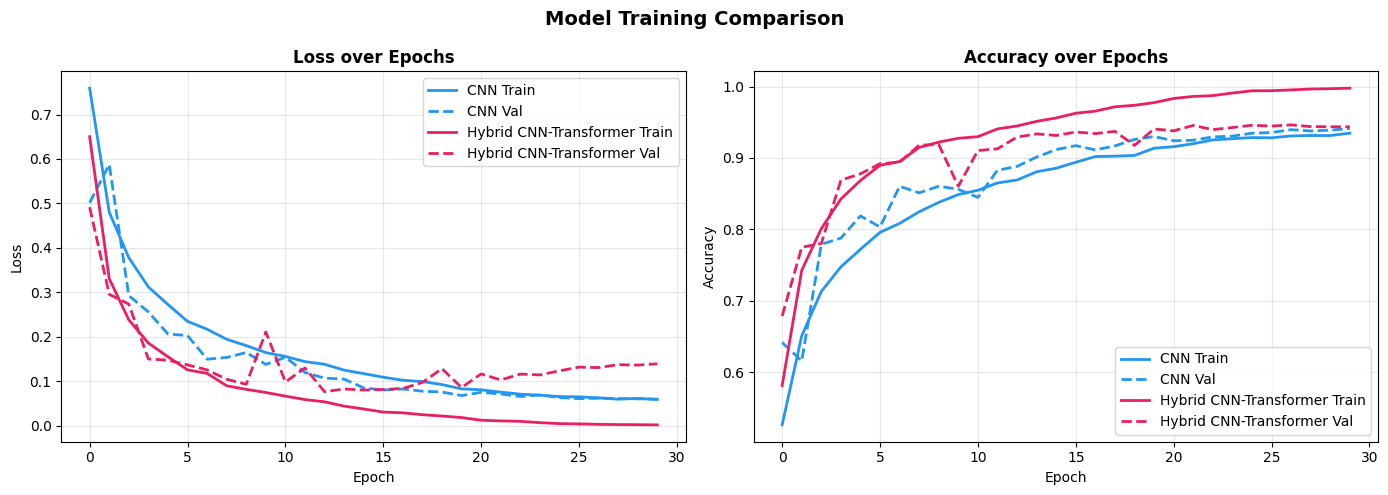

In [26]:
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#E91E63', '#4CAF50']
    for hist, name, col in zip(histories, names, colors):
        axes[0].plot(hist['train_loss'], label=f'{name} Train', color=col, linewidth=2)
        axes[0].plot(hist['val_loss'],   label=f'{name} Val',   color=col,
                     linewidth=2, linestyle='--')
        axes[1].plot(hist['train_acc'],  label=f'{name} Train', color=col, linewidth=2)
        axes[1].plot(hist['val_acc'],    label=f'{name} Val',   color=col,
                     linewidth=2, linestyle='--')

    axes[0].set_title('Loss over Epochs', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title('Accuracy over Epochs', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Model Training Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

plot_history(
    [cnn_history, hybrid_history],
    ['CNN', 'Hybrid CNN-Transformer']
)
# Add vit_history to the list if ViT training was run

## 🎯 STEP 13 — Evaluation: Classification Report & Confusion Matrix


===== cnn — Test Set Evaluation =====
Overall Accuracy : 0.9322 (93.22%)

Classification Report:
              precision    recall  f1-score   support

      Center     0.9587    0.9683    0.9635       600
       Donut     0.9451    0.9750    0.9598       600
    Edge-Loc     0.8998    0.8983    0.8991       600
   Edge-Ring     0.9913    0.9517    0.9711       600
         Loc     0.8596    0.8467    0.8531       600
   Near-full     0.9610    0.9850    0.9728       600
      Random     0.9418    0.9433    0.9425       600
     Scratch     0.9042    0.8967    0.9004       600
        none     0.9281    0.9250    0.9265       600

    accuracy                         0.9322      5400
   macro avg     0.9322    0.9322    0.9321      5400
weighted avg     0.9322    0.9322    0.9321      5400



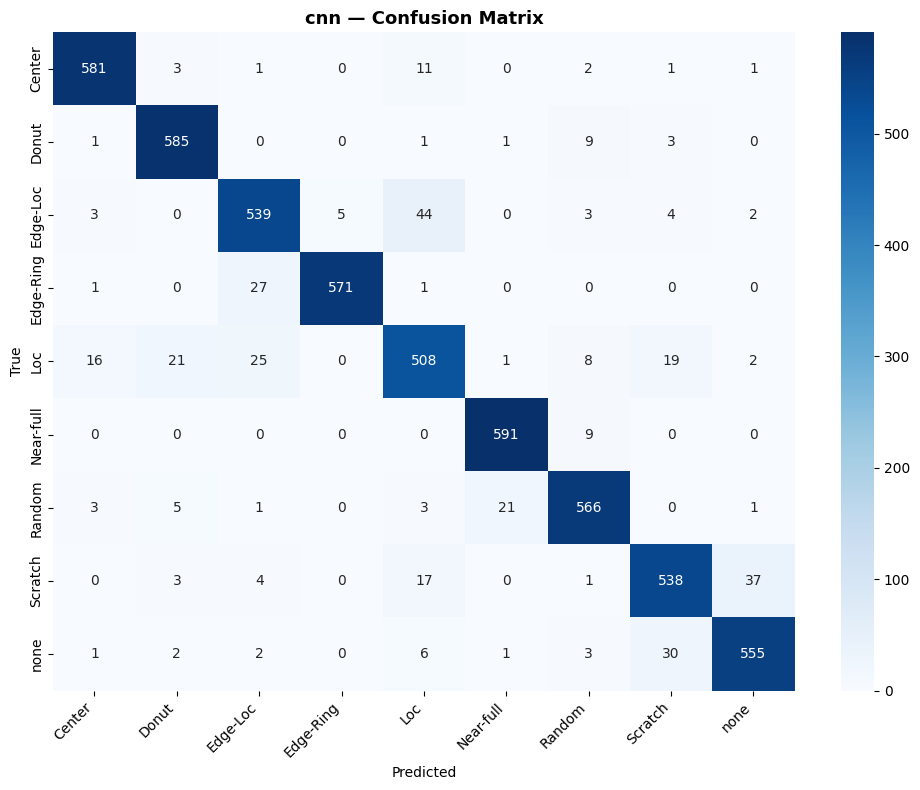

In [27]:
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

def evaluate_model(model, test_loader, class_names, model_name='Model'):
    """Evaluate model and print metrics."""
    model.load_state_dict(torch.load(f'{GDRIVE_BASE}/best_{model_name}.pth', map_location=DEVICE))
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    print(f'\n===== {model_name} — Test Set Evaluation =====')
    acc = accuracy_score(all_labels, all_preds)
    print(f'Overall Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds,
                                target_names=class_names, digits=4))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(f'{GDRIVE_BASE}/confusion_matrix_{model_name}.png', dpi=150)
    plt.show()
    return all_preds, all_labels

cnn_preds, cnn_labels = evaluate_model(
    cnn_model, test_loader, CLASS_NAMES, 'cnn')


===== cnn — Test Set Evaluation =====
Overall Accuracy : 0.9322 (93.22%)

Classification Report:
              precision    recall  f1-score   support

      Center     0.9587    0.9683    0.9635       600
       Donut     0.9451    0.9750    0.9598       600
    Edge-Loc     0.8998    0.8983    0.8991       600
   Edge-Ring     0.9913    0.9517    0.9711       600
         Loc     0.8596    0.8467    0.8531       600
   Near-full     0.9610    0.9850    0.9728       600
      Random     0.9418    0.9433    0.9425       600
     Scratch     0.9042    0.8967    0.9004       600
        none     0.9281    0.9250    0.9265       600

    accuracy                         0.9322      5400
   macro avg     0.9322    0.9322    0.9321      5400
weighted avg     0.9322    0.9322    0.9321      5400



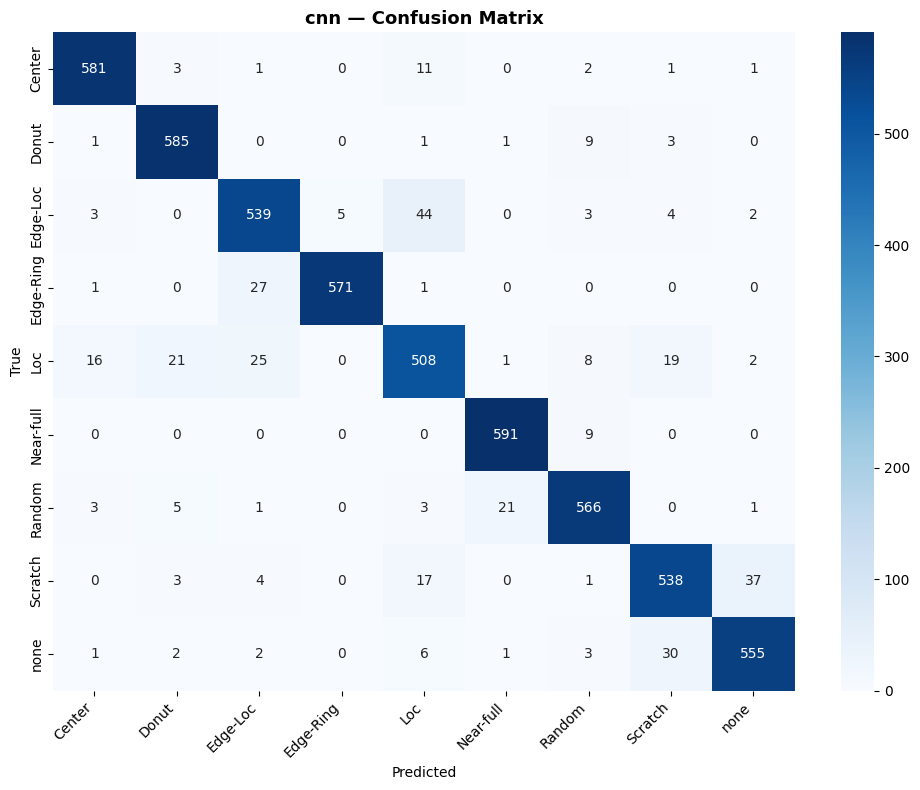


===== vit — Test Set Evaluation =====
Overall Accuracy : 0.8928 (89.28%)

Classification Report:
              precision    recall  f1-score   support

      Center     0.9762    0.9567    0.9663       600
       Donut     0.9424    0.9550    0.9487       600
    Edge-Loc     0.8431    0.9133    0.8768       600
   Edge-Ring     0.9761    0.9533    0.9646       600
         Loc     0.8605    0.7300    0.7899       600
   Near-full     0.9443    0.9883    0.9658       600
      Random     0.9305    0.9150    0.9227       600
     Scratch     0.7561    0.7283    0.7419       600
        none     0.8100    0.8950    0.8504       600

    accuracy                         0.8928      5400
   macro avg     0.8932    0.8928    0.8919      5400
weighted avg     0.8932    0.8928    0.8919      5400



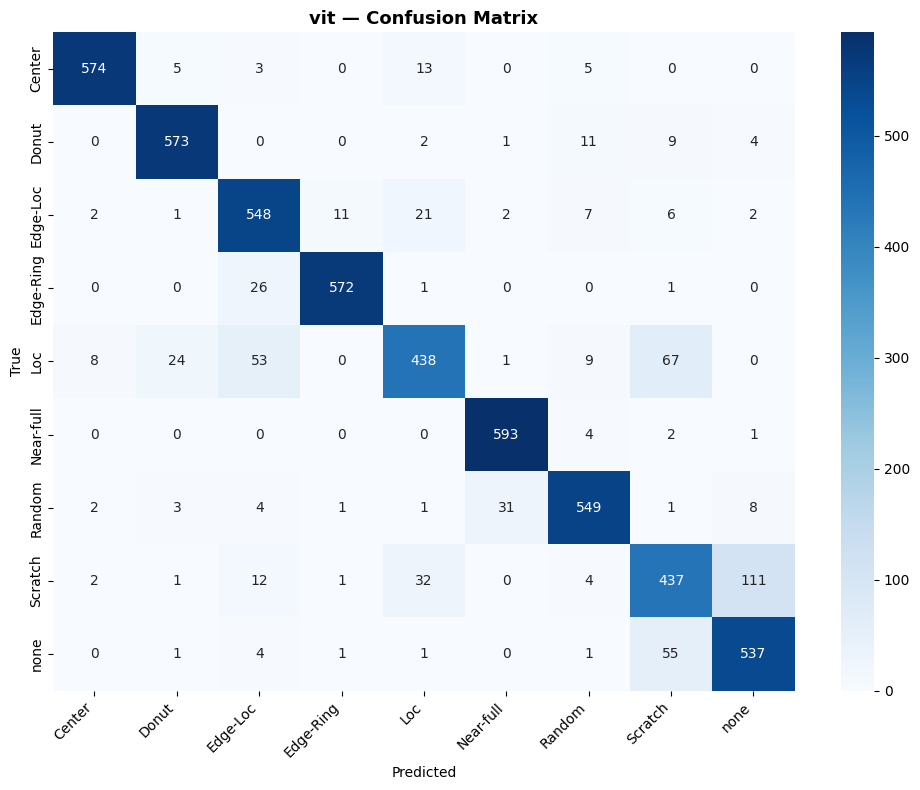


===== hybrid — Test Set Evaluation =====
Overall Accuracy : 0.9483 (94.83%)

Classification Report:
              precision    recall  f1-score   support

      Center     0.9793    0.9483    0.9636       600
       Donut     0.9656    0.9817    0.9736       600
    Edge-Loc     0.9157    0.9417    0.9285       600
   Edge-Ring     0.9817    0.9850    0.9834       600
         Loc     0.8705    0.8850    0.8777       600
   Near-full     0.9868    0.9950    0.9909       600
      Random     0.9603    0.9667    0.9635       600
     Scratch     0.9255    0.9117    0.9186       600
        none     0.9517    0.9200    0.9356       600

    accuracy                         0.9483      5400
   macro avg     0.9486    0.9483    0.9484      5400
weighted avg     0.9486    0.9483    0.9484      5400



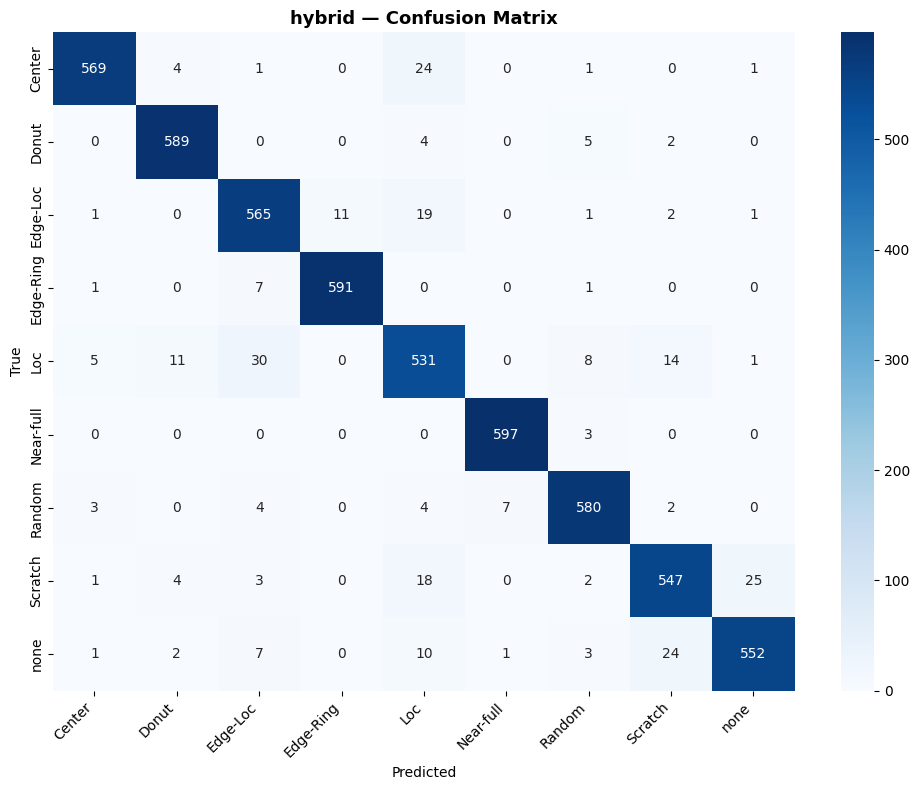

In [28]:
# ✅ 9-CLASS FIX: Evaluate ALL 3 classification models
cnn_preds,    cnn_labels    = evaluate_model(
    cnn_model,    test_loader,     CLASS_NAMES, 'cnn')

vit_preds,    vit_labels    = evaluate_model(
    vit_model,    vit_test_loader, CLASS_NAMES, 'vit')

hybrid_preds, hybrid_labels = evaluate_model(
    hybrid_model, test_loader,     CLASS_NAMES, 'hybrid')


## 🎯 STEP 14 — Model Comparison Summary


9-CLASS MODEL COMPARISON
                   Model  Accuracy  F1 (macro)
  Hybrid CNN-Transformer  0.948333    0.948353
            CNN Baseline  0.932222    0.932101
Vision Transformer (ViT)  0.892778    0.891897


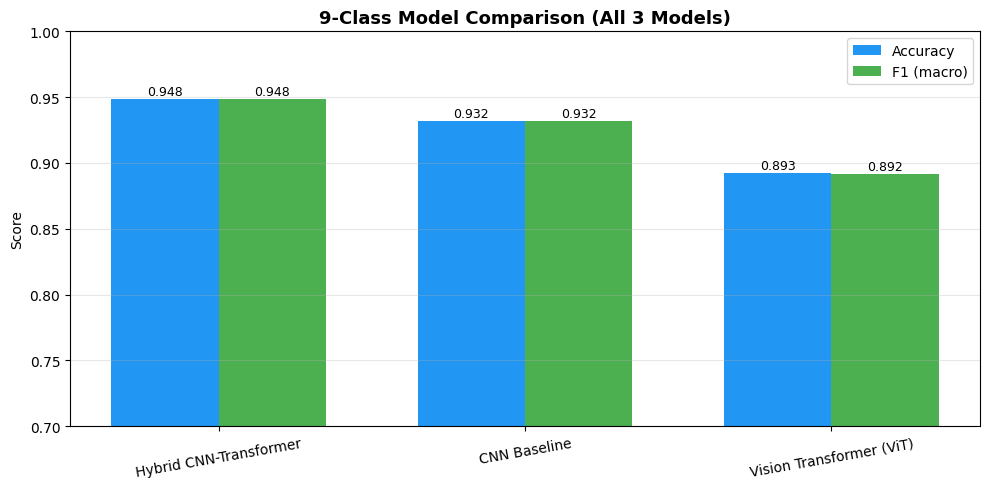

In [29]:
from sklearn.metrics import accuracy_score, f1_score

# ✅ 9-CLASS FIX: All 3 classification models compared
results = {
    'Model'     : ['CNN Baseline', 'Vision Transformer (ViT)', 'Hybrid CNN-Transformer'],
    'Accuracy'  : [
        accuracy_score(cnn_labels,    cnn_preds),
        accuracy_score(vit_labels,    vit_preds),
        accuracy_score(hybrid_labels, hybrid_preds),
    ],
    'F1 (macro)': [
        f1_score(cnn_labels,    cnn_preds,    average='macro'),
        f1_score(vit_labels,    vit_preds,    average='macro'),
        f1_score(hybrid_labels, hybrid_preds, average='macro'),
    ],
}

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print('\n9-CLASS MODEL COMPARISON')
print('=' * 55)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df['Accuracy'],   width, label='Accuracy',  color='#2196F3')
ax.bar(x + width/2, results_df['F1 (macro)'], width, label='F1 (macro)',color='#4CAF50')
ax.set_xticks(x); ax.set_xticklabels(results_df['Model'], rotation=10)
ax.set_ylim(0.7, 1.0); ax.set_ylabel('Score')
ax.set_title('9-Class Model Comparison (All 3 Models)', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison_9class.png', dpi=150)
plt.show()


## 🎯 STEP 14B — Model D: YOLOv11 for Defect Detection & Localization

**Why YOLO in addition to CNN/ViT?**

| Model type | Task | Output |
|---|---|---|
| CNN / ViT / Hybrid | Classification | *What* defect is it? (class label) |
| **YOLOv11** | **Detection** | *What* AND **WHERE** — bounding boxes on the wafer map |

YOLOv11 uses the **Ultralytics** framework. The wafer maps are converted to YOLO label format
(bounding box of defect pixels with value == 2) before training.

**Weight saved to:** `best_yolo11s.pt`  
**Used in app.py:** Detection tab — draws bounding boxes on uploaded wafer images.


In [30]:
# ── Mount Google Drive to backup weights (survives Colab crashes) ─────────────
from google.colab import drive
import os
drive.mount('/content/drive')
GDRIVE_SAVE = '/content/drive/MyDrive/WaferProject'
os.makedirs(GDRIVE_SAVE, exist_ok=True)
print(f'✅ Drive mounted. Weights will be saved to: {GDRIVE_SAVE}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted. Weights will be saved to: /content/drive/MyDrive/WaferProject


In [31]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.8 MB/s eta 0:00:00


In [32]:
# ═══════════════════════════════════════════════════════════════════════════
# YOLOv11 — Defect Detection + Localization (Bounding Boxes)
#
# WHY YOLO in addition to CNN/ViT?
#   CNN/ViT → classification only  (WHAT defect is it?)
#   YOLO    → detection + location (WHAT defect AND WHERE exactly?)
#
# YOLOv11 gives bounding boxes on the wafer map showing exactly
# which region has the defect — critical for real fab inspection.
# ═══════════════════════════════════════════════════════════════════════════

import os, shutil, yaml, cv2
import numpy as np
from tqdm import tqdm
from pathlib import Path

# ── Step 1: Install YOLOv11 (Ultralytics) ────────────────────────────────
# Already installed in Step 1 via !pip install ultralytics
from ultralytics import YOLO
print(f'✅ Ultralytics YOLO imported')

# ── Step 2: Define YOLO dataset paths ────────────────────────────────────
YOLO_DIR    = Path('/content/drive/MyDrive/wafer_yolo')
IMG_TRAIN   = YOLO_DIR / 'images/train'
IMG_VAL     = YOLO_DIR / 'images/val'
LBL_TRAIN   = YOLO_DIR / 'labels/train'
LBL_VAL     = YOLO_DIR / 'labels/val'

for p in [IMG_TRAIN, IMG_VAL, LBL_TRAIN, LBL_VAL]:
    p.mkdir(parents=True, exist_ok=True)

print('✅ YOLO directory structure created:')
print(f'   {YOLO_DIR}')
print('   images/train  images/val')
print('   labels/train  labels/val')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics YOLO imported
✅ YOLO directory structure created:
   /content/drive/MyDrive/wafer_yolo
   images/train  images/val
   labels/train  labels/val


In [33]:
# ═══════════════════════════════════════════════════════════════════════════
# Convert wafer maps → YOLO format
#
# YOLO label format (one .txt per image):
#   class_id  x_center  y_center  width  height
#   all values normalized 0-1 relative to image size
#
# Bounding box strategy:
#   We find the DEFECT REGION (pixel value == 2) in the wafer map,
#   compute its tight bounding box, and write that as the YOLO label.
#   If no defect pixels exist (class='none'), we skip the image.
# ═══════════════════════════════════════════════════════════════════════════

YOLO_IMG_SIZE  = 224           # YOLO input resolution
YOLO_MAX_TRAIN = 1500          # samples per class for training (T4 safe)
YOLO_MAX_VAL   = 300           # samples per class for validation

# Only use DEFECT classes — skip 'none' (no defect = no bounding box)
YOLO_CLASSES = [c for c in CLASS_NAMES if c != 'none']
print(f'YOLO classes ({len(YOLO_CLASSES)}): {YOLO_CLASSES}')

def wafer_to_yolo_bbox(wafer_arr):
    """
    Extract bounding box of defect region (pixel value == 2).
    Returns (x_center, y_center, width, height) normalized 0-1,
    or None if no defect pixels found.
    """
    defect_mask = (wafer_arr == 2)
    if defect_mask.sum() == 0:
        return None
    rows = np.any(defect_mask, axis=1)
    cols = np.any(defect_mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    H, W = wafer_arr.shape
    x_center = ((cmin + cmax) / 2) / W
    y_center = ((rmin + rmax) / 2) / H
    width    = (cmax - cmin + 1) / W
    height   = (rmax - rmin + 1) / H
    # Clamp to [0.01, 0.99]
    x_center = np.clip(x_center, 0.01, 0.99)
    y_center = np.clip(y_center, 0.01, 0.99)
    width    = np.clip(width,    0.01, 0.99)
    height   = np.clip(height,   0.01, 0.99)
    return x_center, y_center, width, height

def save_yolo_sample(wafer, cls_name, idx, split='train'):
    """
    Save one wafer as PNG image + YOLO .txt label.
    Returns True if saved, False if skipped (no defect pixels).
    """
    arr = np.array(wafer, dtype=np.uint8)
    bbox = wafer_to_yolo_bbox(arr)
    if bbox is None:
        return False
    # Convert to 3-channel uint8 image
    img = (arr * 127).clip(0, 255).astype(np.uint8)
    img = cv2.resize(img, (YOLO_IMG_SIZE, YOLO_IMG_SIZE),
                     interpolation=cv2.INTER_NEAREST)
    img_rgb = np.stack([img]*3, axis=-1)
    # Paths
    img_dir = IMG_TRAIN if split == 'train' else IMG_VAL
    lbl_dir = LBL_TRAIN if split == 'train' else LBL_VAL
    fname   = f'{cls_name}_{idx}'
    cv2.imwrite(str(img_dir / f'{fname}.jpg'), img_rgb)
    cls_id  = YOLO_CLASSES.index(cls_name)
    x, y, w, h = bbox
    with open(lbl_dir / f'{fname}.txt', 'w') as f:
        f.write(f'{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n')
    return True

# ── Convert labeled data to YOLO format ──────────────────────────────────
print('Converting wafer maps to YOLO format...')
total_saved = 0

for cls_name in tqdm(YOLO_CLASSES, desc='Classes'):
    cls_df = labeled_data[labeled_data['failureType'] == cls_name]
    wafers = cls_df['waferMap'].tolist()
    np.random.shuffle(wafers)  # shuffle before split

    # Train samples
    saved_train = 0
    for i, w in enumerate(wafers):
        if saved_train >= YOLO_MAX_TRAIN:
            break
        if save_yolo_sample(w, cls_name, i, split='train'):
            saved_train += 1

    # Val samples (from remaining wafers)
    saved_val = 0
    for i, w in enumerate(wafers[saved_train:]):
        if saved_val >= YOLO_MAX_VAL:
            break
        if save_yolo_sample(w, cls_name, saved_train + i, split='val'):
            saved_val += 1

    total_saved += saved_train + saved_val
    print(f'  {cls_name:12s}: {saved_train} train | {saved_val} val')

print(f'\n✅ Total YOLO samples saved: {total_saved:,}')
print(f'   Train images: {len(list(IMG_TRAIN.glob("*.jpg"))):,}')
print(f'   Val   images: {len(list(IMG_VAL.glob("*.jpg"))):,}')

YOLO classes (8): ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']
Converting wafer maps to YOLO format...


Classes:  12%|█▎        | 1/8 [00:52<06:05, 52.18s/it]

  Center      : 1500 train | 300 val


Classes:  25%|██▌       | 2/8 [01:04<02:51, 28.62s/it]

  Donut       : 555 train | 0 val


...

Classes:  88%|████████▊ | 7/8 [03:27<00:23, 23.85s/it]

  Random      : 866 train | 0 val


Classes: 100%|██████████| 8/8 [03:55<00:00, 29.39s/it]

  Scratch     : 1193 train | 0 val

✅ Total YOLO samples saved: 9,963


   Train images: 8,763
   Val   images: 1,200


In [34]:
# ── Write dataset.yaml (YOLO config file) ────────────────────────────────
dataset_yaml = {
    'path'  : str(YOLO_DIR),
    'train' : 'images/train',
    'val'   : 'images/val',
    'nc'    : len(YOLO_CLASSES),
    'names' : YOLO_CLASSES
}

yaml_path = YOLO_DIR / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print('✅ dataset.yaml written:')
print(open(yaml_path).read())

# ── Verify a sample label ────────────────────────────────────────────────
sample_lbl = list(LBL_TRAIN.glob('*.txt'))[0]
sample_img = IMG_TRAIN / (sample_lbl.stem + '.jpg')
print(f'Sample label file : {sample_lbl.name}')
print(f'Label content     : {open(sample_lbl).read().strip()}')
print(f'  → format: class_id  x_center  y_center  width  height (all 0-1)')

✅ dataset.yaml written:
names:
- Center
- Donut
- Edge-Loc
- Edge-Ring
- Loc
- Near-full
- Random
- Scratch
nc: 8
path: /content/drive/MyDrive/wafer_yolo
train: images/train
val: images/val

Sample label file : Center_0.txt
Label content     : 0 0.483871 0.485714 0.990000 0.990000
  → format: class_id  x_center  y_center  width  height (all 0-1)


In [35]:
# ── Free all classification models before YOLO eval ──────────────────────────
# YOLO is completely independent — deleting these has zero effect on YOLO results
import gc, torch
for m_name in ['cnn_model', 'vit_model', 'hybrid_model', 'ae_model']:
    try:
        exec(f'del {m_name}')
    except: pass
gc.collect(); torch.cuda.empty_cache()
print('✅ Previous models cleared from VRAM')
print_memory()

✅ Previous models cleared from VRAM
RAM  : 7.1 GB used / 13.6 GB total  (56.3% used)
VRAM : 0.02 GB used / 15.6 GB total


In [36]:
# ── Load YOLOv11n (nano = fastest, good for T4) ───────────────────────────
# Model variants: yolo11n (nano) → yolo11s → yolo11m → yolo11l → yolo11x
# For T4 GPU: yolo11s gives better accuracy with acceptable speed
yolo_model = YOLO('yolo11s.pt')   # auto-downloads pretrained weights

print('✅ YOLOv11s loaded')
print(f'   Parameters: {sum(p.numel() for p in yolo_model.model.parameters()):,}')

# ── Train YOLOv11 on wafer dataset ───────────────────────────────────────
results = yolo_model.train(
    data     = str(yaml_path),
    epochs   = 15,             # 30 epochs sufficient for wafer maps
    imgsz    = YOLO_IMG_SIZE,  # 224
    batch    = 32,             # T4 safe with yolo11s
    device   = 0,              # GPU 0 (T4)
    workers  = 2,
    project  = '/content/yolo_runs',
    name     = 'wafer_yolo11s',
    exist_ok = True,
    patience = 10,             # early stopping if no improvement for 10 epochs
    save     = True,
    plots    = True,           # saves training plots automatically
    # Augmentation (YOLO has built-in aug — disable to avoid double augmentation)
    hsv_h    = 0.0,            # no hue shift (wafer maps are grayscale)
    hsv_s    = 0.0,            # no saturation shift
    hsv_v    = 0.3,            # slight brightness variation
    flipud   = 0.5,            # vertical flip
    fliplr   = 0.5,            # horizontal flip
    degrees  = 30,             # rotation
    translate= 0.1,            # translation
    scale    = 0.1,            # scale
)

print('\n✅ YOLOv11 training complete!')
print(f'Best weights saved at: /content/yolo_runs/wafer_yolo11s/weights/best.pt')

# ── Save weights to Google Drive immediately (survives session crashes) ───────
try:
    import shutil
    shutil.copy('/content/yolo_runs/wafer_yolo11s/weights/best.pt',
                f'{GDRIVE_SAVE}/best_yolo11s.pt')
    print(f'✅ YOLO weights backed up to Google Drive')
except Exception as e:
    print(f'⚠️  Drive backup failed (mount Drive first): {e}')


✅ YOLOv11s loaded
   Parameters: 9,458,752
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/wafer_yolo/dataset.yaml, degrees=30, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wafer_yolo11s, nbs=64, nms=False, opset=None, opt

In [37]:
# ── Free all classification models before YOLO eval ──────────────────────────
# YOLO is completely independent — deleting these has zero effect on YOLO results
import gc, torch
for m_name in ['cnn_model', 'vit_model', 'hybrid_model', 'ae_model']:
    try:
        exec(f'del {m_name}')
    except: pass
gc.collect(); torch.cuda.empty_cache()
print('✅ Previous models cleared from VRAM')
print_memory()


# ── Load YOLO weights from disk ───────────────────────────────────────────────
# If session crashed: reload from Google Drive instead:
# best_yolo = YOLO(f'{GDRIVE_SAVE}/best_yolo11s.pt')
best_yolo = YOLO('/content/yolo_runs/wafer_yolo11s/weights/best.pt')

metrics = best_yolo.val(
    data    = str(yaml_path),
    imgsz   = YOLO_IMG_SIZE,
    batch   = 16,            # reduced from 32 — prevents VRAM spike during eval
    device  = 0,
    plots   = True,
    verbose = False,
)

print('\n===== YOLOv11 Evaluation Results =====')
print(f'mAP@0.5      : {metrics.box.map50:.4f}')
print(f'mAP@0.5:0.95 : {metrics.box.map:.4f}')
print(f'Precision    : {metrics.box.mp:.4f}')
print(f'Recall       : {metrics.box.mr:.4f}')
print('\nPer-class mAP@0.5:')
for cls, ap in zip(YOLO_CLASSES, metrics.box.ap50):
    print(f'  {cls:12s}: {ap:.4f}')

# NOTE: best_yolo kept alive — needed by yolo-infer cell below
print('✅ best_yolo ready for inference')
print_memory()


✅ Previous models cleared from VRAM
RAM  : 10.1 GB used / 13.6 GB total  (79.5% used)
VRAM : 0.21 GB used / 15.6 GB total
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,896 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 6.6±3.4 MB/s, size: 12.8 KB)
val: Scanning /content/drive/MyDrive/wafer_yolo/labels/val.cache... 1200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1200/1200 335.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 75/75 4.9it/s 15.2s
                   all       1200       1200      0.868      0.883      0.923      0.806
Speed: 0.2ms preprocess, 2.2ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val

===== YOLOv11 Evaluation Results =====
mAP@0.5      : 0.9228
mAP@0.5:0.95 : 0.8057
Precision    : 0.8679
Recall       : 0.8833

Per-class m

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def get_yolo_bbox_largest_defect(wafer):
    """
    Returns YOLO formatted bounding box [x_center, y_center, width, height]
    for the MOSTLY defective area (largest connected component where value == 2).
    Coordinates are normalized between 0 and 1.
    """
    arr = np.array(wafer, dtype=np.uint8)

    # Create a binary mask where defects (value 2) are 255, else 0
    defect_mask = np.where(arr == 2, 255, 0).astype(np.uint8)

    # Find contours (outlines of the defect areas)
    contours, _ = cv2.findContours(defect_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return None # No defects found

    # Get the largest contour by area (filters out tiny noise dots)
    largest_contour = max(contours, key=cv2.contourArea)

    # Get bounding box for the largest contour
    x, y, w, h = cv2.boundingRect(largest_contour)

    img_h, img_w = arr.shape

    # Calculate center points
    x_center = x + (w / 2.0)
    y_center = y + (h / 2.0)

    # Normalize by image dimensions for YOLO standard format
    x_center_norm = x_center / img_w
    y_center_norm = y_center / img_h
    w_norm = w / img_w
    h_norm = h / img_h

    return [x_center_norm, y_center_norm, w_norm, h_norm]

def draw_yolo_bbox(wafer, cls_name="Detection"):
    """
    Visualizes the raw wafer map and overlays the calculated YOLO bounding box.
    """
    bbox = get_yolo_bbox_largest_defect(wafer)

    img = np.array(wafer)
    img_h, img_w = img.shape

    fig, ax = plt.subplots(1, figsize=(4, 4))
    ax.imshow(img, cmap='plasma')
    ax.set_title(f'YOLO BBox: {cls_name}', fontsize=10, fontweight='bold')
    ax.axis('off')

    if bbox:
        x_center, y_center, w, h = bbox

        # Convert back from YOLO normalized format to absolute coordinates for Matplotlib
        abs_x = (x_center - w/2) * img_w
        abs_y = (y_center - h/2) * img_h
        abs_w = w * img_w
        abs_h = h * img_h

        # Create a Rectangle patch and add it to the plot
        rect = patches.Rectangle((abs_x, abs_y), abs_w, abs_h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

    plt.show()

# ==========================================
# Example Usage:
# Fetch a sample from your existing dataframe
# ==========================================
# cls_to_test = 'Edge-Ring'
# sample_wafer = labeled_data[labeled_data['failureType'] == cls_to_test]['waferMap'].iloc[0]
# yolo_bbox = get_yolo_bbox_largest_defect(sample_wafer)
# print(f"YOLO format [x_center, y_center, w, h]: {yolo_bbox}")
#
# # Display it:
# draw_yolo_bbox(sample_wafer, cls_name=cls_to_test)


YOLO format [x_center, y_center, w, h]: [0.7884615384615384, 0.40384615384615385, 0.19230769230769232, 0.19230769230769232]


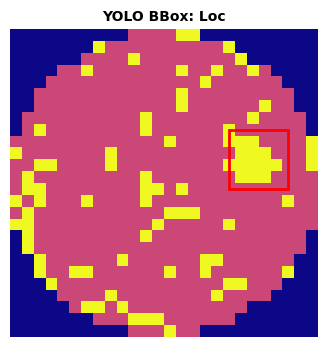

In [39]:
cls_to_test = 'Loc'
sample_wafer = labeled_data[labeled_data['failureType'] == cls_to_test]['waferMap'].iloc[20]
yolo_bbox = get_yolo_bbox_largest_defect(sample_wafer)
print(f"YOLO format [x_center, y_center, w, h]: {yolo_bbox}")
#
# # Display it:
draw_yolo_bbox(sample_wafer, cls_name=cls_to_test)

Randomly selected Index: 20
Defect Class: none
YOLO Box [x_center, y_center, width, height]: [0.96875, 0.4666666666666667, 0.0625, 0.08888888888888889]


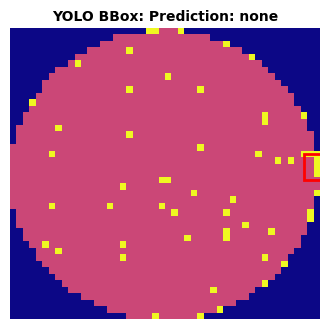

In [40]:
import random

def predict_yolo_single(df):
    """
    Picks a random wafer map from your dataset dataframe, computes the YOLO bounding box
    for the 'mostly defected area', and displays it.
    """
    # 1. Pick a random row from the dataframe
    random_idx = 20
    row = df.iloc[random_idx]

    # Extract the raw wafer array and its real class name
    sample_wafer = row['waferMap']
    true_class = row['failureType']

    print(f"Randomly selected Index: {random_idx}")
    print(f"Defect Class: {true_class}")

    # 2. Calculate YOLO BBox using the OpenCV function we made earlier
    yolo_bbox = get_yolo_bbox_largest_defect(sample_wafer)

    if yolo_bbox is None:
        # If the wafer array contains no defected pixels (value == 2)
        print("No defects (value=2) found in this wafer!")
    else:
        # Print the YOLO coordinates
        print(f"YOLO Box [x_center, y_center, width, height]: {yolo_bbox}")

    # 3. Display the image with the red bounding box overlaid
    draw_yolo_bbox(sample_wafer, cls_name=f"Prediction: {true_class}")


# ==========================================
# Run the function to see the result!
# ==========================================
predict_yolo_single(labeled_data)


Running YOLOv11 inference on 6 sample images...


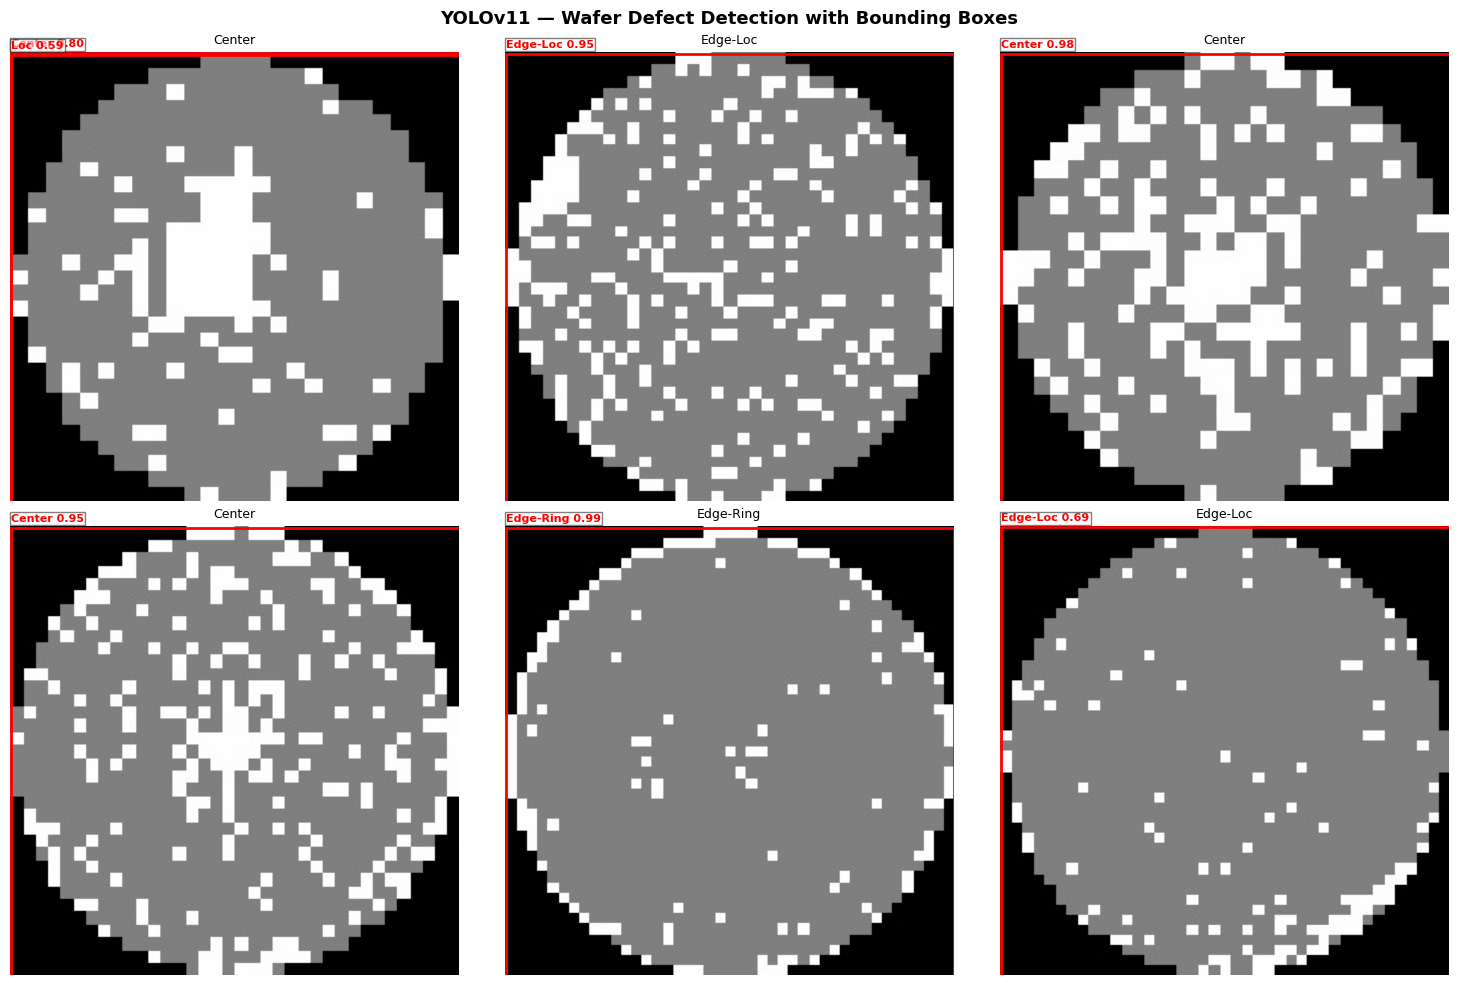

✅ Saved: yolo_detections_grid.png
✅ best_yolo freed from VRAM
RAM  : 10.3 GB used / 13.6 GB total  (80.5% used)
VRAM : 0.21 GB used / 15.6 GB total


In [41]:
# ── Predict on sample images — visualize bounding boxes ──────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def predict_yolo_single(img_path, conf_threshold=0.25):
    """
    Run YOLOv11 on a single wafer image.
    Draws bounding boxes with class names and confidence scores.
    """
    results = best_yolo.predict(
        source    = img_path,
        conf      = conf_threshold,
        imgsz     = YOLO_IMG_SIZE,
        device    = 0,
        save      = False,
        verbose   = False
    )
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(img_rgb, cmap='plasma')

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cls_id  = int(box.cls[0])
            conf    = float(box.conf[0])
            label   = f'{YOLO_CLASSES[cls_id]} {conf:.2f}'
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1-4, label, color='red',
                    fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.6, pad=1))

    fname = Path(img_path).stem
    ax.set_title(f'YOLOv11 Detection: {fname}', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'yolo_pred_{fname}.png', dpi=120)
    plt.show()

# Run on 6 random val images
val_imgs = list(IMG_VAL.glob('*.jpg'))
sample_imgs = np.random.choice(val_imgs, min(6, len(val_imgs)), replace=False)

print(f'Running YOLOv11 inference on {len(sample_imgs)} sample images...')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_path in enumerate(sample_imgs):
    results = best_yolo.predict(
        source=str(img_path), conf=0.25,
        imgsz=YOLO_IMG_SIZE, device=0, verbose=False)
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    axes[idx].imshow(img, cmap='plasma')
    for r in results:
        for box in r.boxes:
            x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            rect = patches.Rectangle((x1,y1),x2-x1,y2-y1,
                                      linewidth=2,edgecolor='red',facecolor='none')
            axes[idx].add_patch(rect)
            axes[idx].text(x1,y1-3,f'{YOLO_CLASSES[cls_id]} {conf:.2f}',
                           color='red',fontsize=8,fontweight='bold',
                           bbox=dict(facecolor='white',alpha=0.5,pad=1))
    axes[idx].set_title(Path(img_path).stem.split('_')[0], fontsize=9)
    axes[idx].axis('off')

plt.suptitle('YOLOv11 — Wafer Defect Detection with Bounding Boxes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('yolo_detections_grid.png', dpi=130)
plt.show()
print('✅ Saved: yolo_detections_grid.png')

# ── Free YOLO after inference is done ────────────────────────────────────────
del best_yolo
gc.collect(); torch.cuda.empty_cache()
print('✅ best_yolo freed from VRAM')
print_memory()


In [42]:
# ── Final model comparison including YOLO ────────────────────────────────
print('=' * 55)
print('COMPLETE MODEL COMPARISON')
print('=' * 55)
print(f'{'Model':<25} {'Task':<20} {'Key Metric'}')
print('-' * 55)
print(f'{'CNN Baseline':<25} {'Classification':<20} Accuracy: {accuracy_score(cnn_labels, cnn_preds):.4f}')
print(f'{'Hybrid CNN-Transformer':<25} {'Classification':<20} Accuracy: {accuracy_score(hybrid_labels, hybrid_preds):.4f}')
print(f'{'Vision Transformer (ViT)':<25} {'Classification':<20} Accuracy: see vit eval cell')
print(f'{'YOLOv11s':<25} {'Detection+Location':<20} mAP@0.5: {metrics.box.map50:.4f}')
print('=' * 55)
print()
print('KEY DIFFERENCE:')
print('  CNN / ViT / Hybrid → tells you WHAT the defect is')
print('  YOLOv11           → tells you WHAT + WHERE (bounding box)')
print('  Both are needed in a real fab inspection system')

COMPLETE MODEL COMPARISON
Model                     Task                 Key Metric
-------------------------------------------------------
CNN Baseline              Classification       Accuracy: 0.9322
Hybrid CNN-Transformer    Classification       Accuracy: 0.9483
Vision Transformer (ViT)  Classification       Accuracy: see vit eval cell
YOLOv11s                  Detection+Location   mAP@0.5: 0.9228

KEY DIFFERENCE:
  CNN / ViT / Hybrid → tells you WHAT the defect is
  YOLOv11           → tells you WHAT + WHERE (bounding box)
  Both are needed in a real fab inspection system


## 🚨 STEP 15 — EfficientAD: Unsupervised Anomaly Detection

**WaferAutoencoder** — a lightweight conv autoencoder trained **only on normal (none-class)** wafers.

| | |
|---|---|
| Architecture | Encoder (Conv×3 + MaxPool) → Decoder (ConvTranspose×2 + Conv) |
| Training | MSE reconstruction loss on normal wafers only |
| Anomaly score | Pixel-wise MSE between input and reconstruction |
| Threshold | mean + 2σ of normal-wafer reconstruction errors |
| Usage in app | `best_autoencoder.pth` loaded by `EfficientAD` tab in `app.py` |

The threshold is **saved inside** `best_autoencoder.pth` as the `anomaly_threshold` key, so the Streamlit app can use it automatically without re-computing.


In [43]:
# ── Reload models that were freed before YOLO ────────────────────────────────
cnn_model    = WaferCNN(NUM_CLASSES).to(DEVICE)
hybrid_model = HybridCNNTransformer(NUM_CLASSES).to(DEVICE)

# ── Reload saved weights from Drive (models were deleted before YOLO) ────────
cnn_model.load_state_dict(torch.load(f'{GDRIVE_BASE}/best_cnn.pth', map_location=DEVICE))
cnn_model.eval()
hybrid_model.load_state_dict(torch.load(f'{GDRIVE_BASE}/best_hybrid.pth', map_location=DEVICE))
hybrid_model.eval()
print('✅ CNN & Hybrid weights reloaded from Drive')

class WaferAutoencoder(nn.Module):
    """Trains ONLY on normal wafers. High reconstruction error = unknown defect."""
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 8,  3, padding=1), nn.ReLU())
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(16, 32, 2, stride=2), nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1), nn.Sigmoid())
    def forward(self, x): return self.decoder(self.encoder(x))

ae_model = WaferAutoencoder().to(DEVICE)

# ── Normal-only loader using DiskDataset (no X_normal array in RAM) ───────────
none_label     = le.transform(['none'])[0]
normal_mask    = y_train == none_label
normal_indices = idx_train[normal_mask]
normal_labels  = y_train[normal_mask]

normal_loader = DataLoader(
    DiskDataset(normal_indices, normal_labels, SAVE_DIR),
    batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

print(f'Normal (none) training samples: {len(normal_indices):,}')
print_memory()


✅ CNN & Hybrid weights reloaded from Drive
Normal (none) training samples: 2,800
RAM  : 10.2 GB used / 13.6 GB total  (80.4% used)
VRAM : 0.25 GB used / 15.6 GB total


In [44]:
ae_optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)
ae_criterion = nn.MSELoss()

ae_losses = []
AE_EPOCHS = 20

print('Training Autoencoder on normal wafers...')
for epoch in range(1, AE_EPOCHS + 1):
    ae_model.train()
    total_loss = 0
    for imgs, _ in normal_loader:
        imgs = imgs.to(DEVICE)
        recon = ae_model(imgs)
        loss = ae_criterion(recon, imgs)
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    avg = total_loss / len(normal_indices)
    ae_losses.append(avg)
    if epoch % 5 == 0:
        print(f'  Epoch {epoch}/{AE_EPOCHS}  Recon Loss: {avg:.6f}')

torch.save(ae_model.state_dict(), 'best_autoencoder.pth')
print('✅ Autoencoder trained.')

Training Autoencoder on normal wafers...
  Epoch 5/20  Recon Loss: 0.023965
  Epoch 10/20  Recon Loss: 0.021735
  Epoch 15/20  Recon Loss: 0.020057
  Epoch 20/20  Recon Loss: 0.019134
✅ Autoencoder trained.


Anomaly Threshold : 0.064299
Anomalies Detected: 220 / 5400
Anomaly Rate      : 4.07%


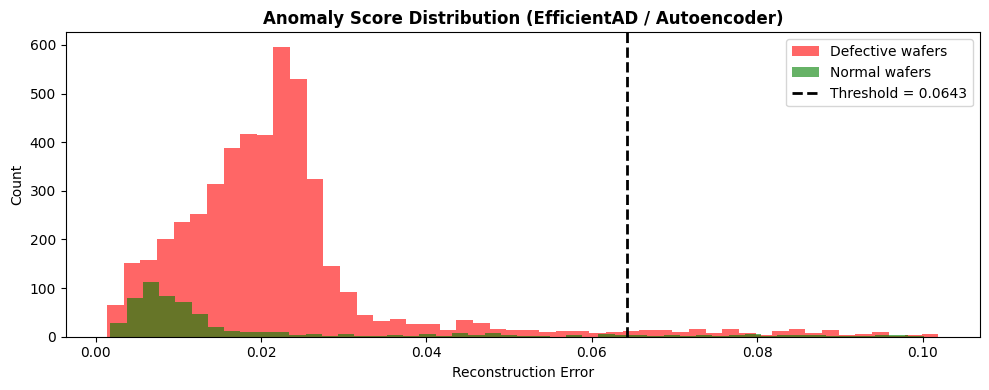

In [45]:
# ── Compute anomaly scores on test set ───────────────────────────────────────
ae_model.eval()
anomaly_scores = []

with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(DEVICE)
        recon = ae_model(imgs)
        pixel_mse = ((recon - imgs) ** 2).mean(dim=(1, 2, 3))
        anomaly_scores.extend(pixel_mse.cpu().numpy())

anomaly_scores = np.array(anomaly_scores)

# Threshold: mean + 2*std on normal validation images
normal_val_mask = y_test == none_label
normal_scores = anomaly_scores[normal_val_mask]
threshold = normal_scores.mean() + 2 * normal_scores.std()
is_anomaly = anomaly_scores > threshold

print(f'Anomaly Threshold : {threshold:.6f}')
print(f'Anomalies Detected: {is_anomaly.sum()} / {len(is_anomaly)}')
print(f'Anomaly Rate      : {is_anomaly.mean()*100:.2f}%')

# Visualise anomaly score distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(anomaly_scores[~normal_val_mask], bins=50, alpha=0.6,
        label='Defective wafers', color='red')
ax.hist(anomaly_scores[ normal_val_mask], bins=50, alpha=0.6,
        label='Normal wafers',   color='green')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold = {threshold:.4f}')
ax.set_title('Anomaly Score Distribution (EfficientAD / Autoencoder)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Reconstruction Error'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('anomaly_distribution.png', dpi=150)
plt.show()

## 🎯 STEP 16 — Single Image Prediction (Inference Demo)

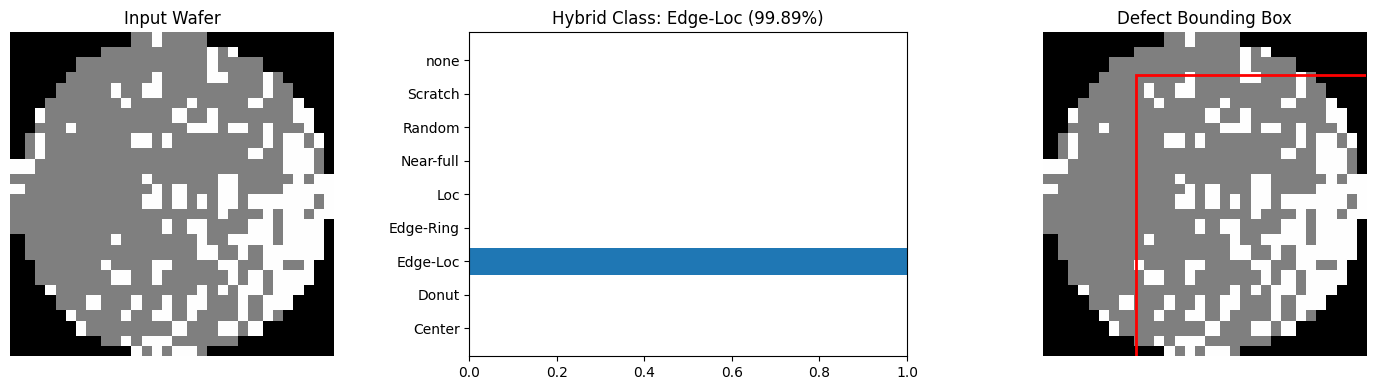

('Edge-Loc', np.float32(0.99893624))

In [124]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def predict_input(hybrid_model, yolo_model, class_names,
                  disk_idx=None, uploaded_img=None, show_ground_truth=True):

    # ── Load trained weights from Drive (fixes near-uniform probability output) ──
    hybrid_model.load_state_dict(torch.load(f'{GDRIVE_BASE}/best_hybrid.pth', map_location=DEVICE))
    hybrid_model.eval()

    # ───── 1. Load Image ─────────────────────────────────────────────────────
    if uploaded_img is not None:
        img = uploaded_img
        is_disk = False
    elif disk_idx is not None:
        img = np.load(f'{SAVE_DIR}/{disk_idx:06d}.npy')
        is_disk = True
    else:
        raise ValueError("Provide either disk_idx or uploaded_img")

    # Ensure 3-channel float32
    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)
    if img.max() <= 1.0:
        img_rgb = (img * 255).astype(np.uint8)
    else:
        img_rgb = img.astype(np.uint8)

    # ───── 2. Tensor + Hybrid Prediction ─────────────────────────────────────
    tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).to(DEVICE).float()
    with torch.no_grad():
        logits = hybrid_model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_cls   = class_names[np.argmax(probs)]
    confidence = probs.max()

    # ───── 3. Plot ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(img_rgb, cmap='plasma')
    axes[0].set_title("Input Wafer")
    axes[0].axis('off')

    axes[1].barh(class_names, probs)
    axes[1].set_xlim(0, 1)
    axes[1].set_title(f'Hybrid Class: {pred_cls} ({confidence:.2%})')

    axes[2].imshow(img_rgb, cmap='plasma')
    axes[2].set_title("Defect Bounding Box")
    axes[2].axis('off')

    if show_ground_truth:
        def get_defect_bbox(img_rgb):
            gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

            # Exclude black background (outside wafer)
            wafer_mask = (gray > 30).astype(np.uint8)

            # Get average brightness INSIDE wafer only
            wafer_pixels = gray[wafer_mask == 1]
            mean_val = np.mean(wafer_pixels)
            std_val  = np.std(wafer_pixels)

            # Defect pixels = significantly brighter than wafer average
            threshold = mean_val + 1.5 * std_val
            defect_bin = (((gray > threshold) & (wafer_mask == 1)) * 255).astype(np.uint8)

            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
            defect_bin = cv2.morphologyEx(defect_bin, cv2.MORPH_CLOSE, kernel)

            contours, _ = cv2.findContours(
                defect_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours:
                return None

            largest = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest) < 10:
                return None
            return cv2.boundingRect(largest)

        bbox = get_defect_bbox(img_rgb)
        if bbox is not None:
            x, y, w, h = bbox
            rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                      edgecolor='red', facecolor='none')
            axes[2].add_patch(rect)

    plt.tight_layout()
    plt.show()
    return pred_cls, confidence

predict_input(hybrid_model, yolo_model, CLASS_NAMES, disk_idx=idx_test[3000])


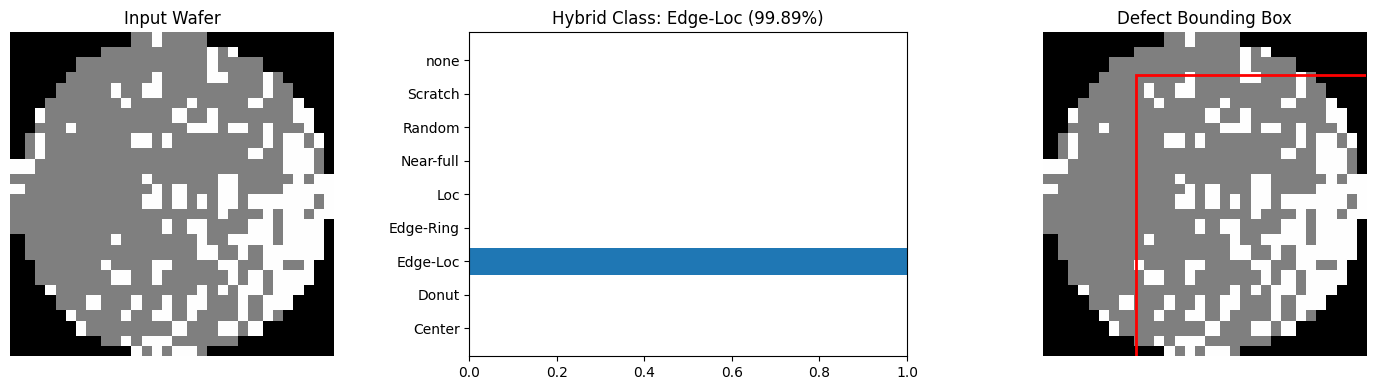

('Edge-Loc', np.float32(0.99893624))

In [113]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def predict_input(hybrid_model, yolo_model, class_names,
                  disk_idx=None, uploaded_img=None, show_ground_truth=True):

    hybrid_model.load_state_dict(torch.load(f'{GDRIVE_BASE}/best_hybrid.pth', map_location=DEVICE))
    hybrid_model.eval()

    # ── 1. Load Image ─────────────────────────────────────────────────────────
    if uploaded_img is not None:
        img = uploaded_img
        is_disk = False
    elif disk_idx is not None:
        img = np.load(f'{SAVE_DIR}/{disk_idx:06d}.npy')
        is_disk = True
    else:
        raise ValueError("Provide either disk_idx or uploaded_img")

    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)
    img = img.astype(np.float32)
    if img.max() > 1.0:
        img = img / 255.0
    img_rgb = (img * 255).astype(np.uint8)

    # ── 2. Predict ────────────────────────────────────────────────────────────
    tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).to(DEVICE).float()
    with torch.no_grad():
        probs = torch.softmax(hybrid_model(tensor), dim=1).cpu().numpy()[0]

    pred_cls   = class_names[np.argmax(probs)]
    confidence = probs.max()

    # ── 3. Bounding Box ───────────────────────────────────────────────────────
    def get_defect_bbox(img_rgb, is_disk):
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
        wafer_mask = (gray > 30).astype(np.uint8)

        if is_disk:
            # Fixed threshold: good_die≈127, defect≈254 → midpoint 180
            defect_bin = (((gray > 180) & (wafer_mask == 1)) * 255).astype(np.uint8)
        else:
            # Uploaded image: Otsu picks threshold automatically
            gray_wafer = cv2.bitwise_and(gray, gray, mask=wafer_mask)
            _, defect_bin = cv2.threshold(
                gray_wafer, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        defect_bin = cv2.morphologyEx(defect_bin, cv2.MORPH_CLOSE, kernel)

        contours, _ = cv2.findContours(
            defect_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None

        # ── Largest contour only (avoids giant box from scattered pixels) ──
        largest = max(contours, key=cv2.contourArea)
        if cv2.contourArea(largest) < 10:
            return None
        return cv2.boundingRect(largest)

    # ── 4. Plot ───────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].imshow(img_rgb, cmap='plasma')
    axes[0].set_title("Input Wafer")
    axes[0].axis('off')

    axes[1].barh(class_names, probs)
    axes[1].set_xlim(0, 1)
    axes[1].set_title(f'Hybrid Class: {pred_cls} ({confidence:.2%})')

    axes[2].imshow(img_rgb, cmap='plasma')
    axes[2].set_title("Defect Bounding Box")
    axes[2].axis('off')

    if show_ground_truth:
        bbox = get_defect_bbox(img_rgb, is_disk)
        if bbox is not None:
            x, y, w, h = bbox
            rect = patches.Rectangle((x, y), w, h, linewidth=2,
                                      edgecolor='red', facecolor='none')
            axes[2].add_patch(rect)

    plt.tight_layout()
    plt.show()
    return pred_cls, confidence

predict_input(hybrid_model, yolo_model, CLASS_NAMES, disk_idx=idx_test[3000])

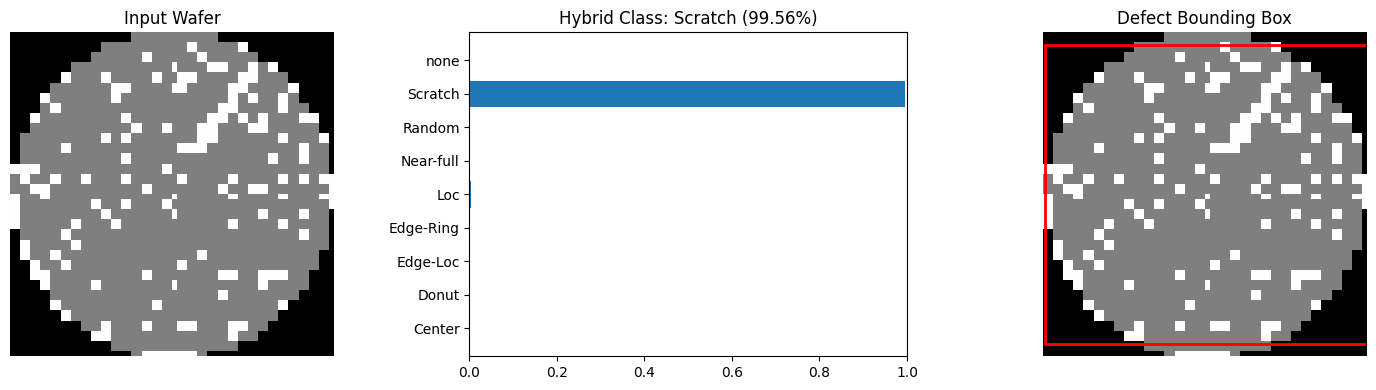

('Scratch', np.float32(0.9956476))

In [108]:
predict_input(hybrid_model, yolo_model, CLASS_NAMES, disk_idx=idx_test[3200])

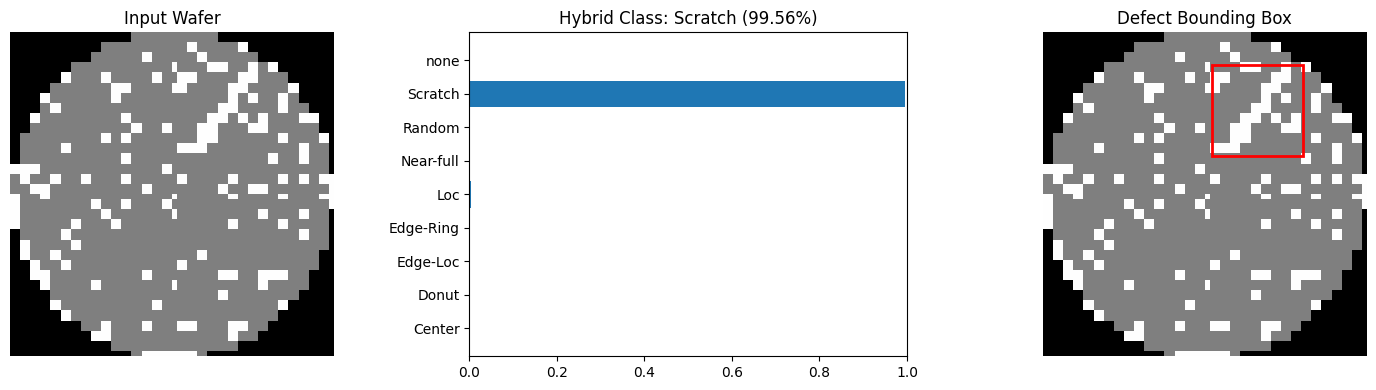

('Scratch', np.float32(0.9956476))

In [106]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def predict_input(hybrid_model, yolo_model, class_names,
                  disk_idx=None, uploaded_img=None, show_ground_truth=True):

    # ───── Load trained weights before inference ─────────────────────────────
    # Fixes near-uniform probability output caused by un-loaded (random) weights
    hybrid_model.load_state_dict(torch.load(f'{GDRIVE_BASE}/best_hybrid.pth', map_location=DEVICE))
    hybrid_model.eval()

    # ───── 1. Load Image ─────
    if uploaded_img is not None:
        img = uploaded_img
    elif disk_idx is not None:
        # Load from saved augmented pool (float32 array scaled 0-1)
        img = np.load(f'{SAVE_DIR}/{disk_idx:06d}.npy')
    else:
        raise ValueError("Provide either disk_idx or uploaded_img")

    # Ensure 3-channel
    if len(img.shape) == 2:
        img = np.stack([img]*3, axis=-1)

    # Convert back to standard RGB (0-255) for display/CV2
    if img.max() <= 1.0:
        img_rgb = (img * 255).astype(np.uint8)
    else:
        img_rgb = img.astype(np.uint8)

    # Tensor for Hybrid CNN-Transformer Classification Model
    tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).to(DEVICE).float()

    # ───── 2. Hybrid Classification Prediction ─────
    with torch.no_grad():
        logits = hybrid_model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_cls   = class_names[np.argmax(probs)]
    confidence = probs.max()

    # ───── 3. Plot Everything ─────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # A) 1st Plot: Clean Input Wafer
    axes[0].imshow(img_rgb, cmap='plasma')
    axes[0].set_title("Input Wafer")
    axes[0].axis('off')

    # B) 2nd Plot: Hybrid Classification Confidence Chart
    axes[1].barh(class_names, probs)
    axes[1].set_xlim(0, 1)
    axes[1].set_title(f'Hybrid Class: {pred_cls} ({confidence:.2%})')

    # C) 3rd Plot: Clean Defect Bounding Box (Red ONLY)
    axes[2].imshow(img_rgb, cmap='plasma')
    axes[2].set_title("Defect Bounding Box")
    axes[2].axis('off')

    # Extract & draw RED ground truth box onto axes[2]
    if show_ground_truth and disk_idx is not None:
        defect_mask = np.where(img_rgb[:, :, 0] > 250, 255, 0).astype(np.uint8)
        contours, _ = cv2.findContours(defect_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if contours:
            largest_contour = max(contours, key=cv2.contourArea)
            x, y, w, h = cv2.boundingRect(largest_contour)

            # Draw real Ground Truth box in RED
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
            axes[2].add_patch(rect)

    plt.tight_layout()
    plt.show()

    return pred_cls, confidence

# ==========================================
# Run it!
# ==========================================
predict_input(hybrid_model, yolo_model, CLASS_NAMES, disk_idx=idx_test[3200])


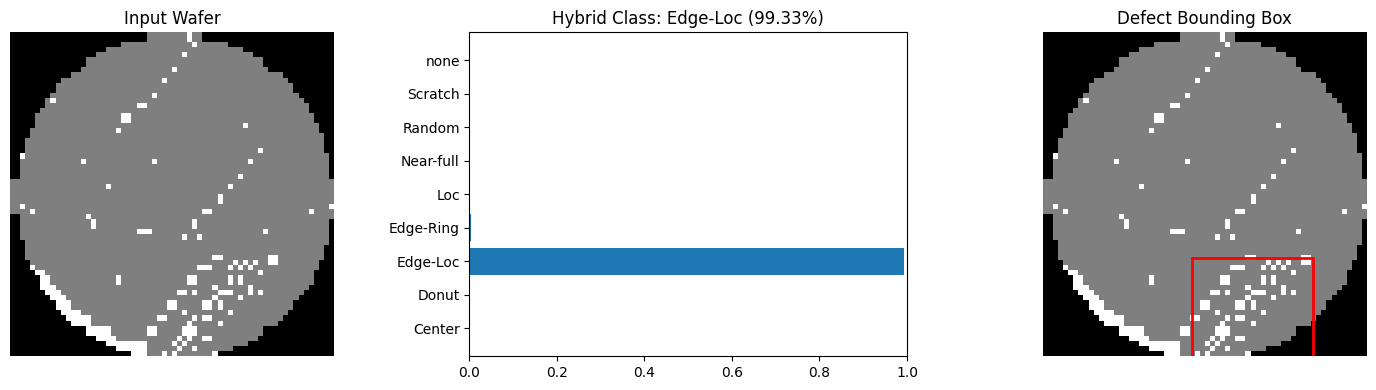

('Edge-Loc', np.float32(0.99331963))

In [131]:
predict_input(hybrid_model, yolo_model, CLASS_NAMES, disk_idx=idx_test[2200])

In [126]:
from google.colab import files
uploaded = files.upload()

In [129]:
from google.colab import files
uploaded = files.upload()

import cv2
import numpy as np

img_path = list(uploaded.keys())[0]
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (64, 64), interpolation=cv2.INTER_NEAREST)  # ← NEAREST, not bilinear
img = img / 255.0


Saving Screenshot 2026-03-29 122313.png to Screenshot 2026-03-29 122313 (5).png


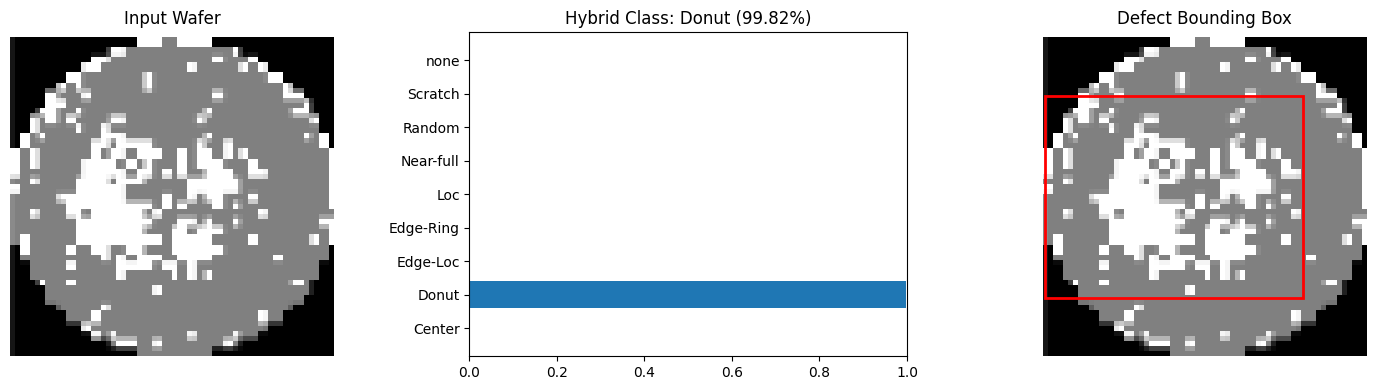

('Donut', np.float32(0.9981509))

In [130]:
predict_input(hybrid_model, yolo_model, CLASS_NAMES,uploaded_img=img)

## 🌐 STEP 17 — Streamlit Deployment App

In [53]:
# ── Step 17: Write app.py ────────────────────────────────────────────────────
# The full app.py (with CNN, ViT, Hybrid, YOLOv11, EfficientAD) is provided
# as a separate file in the project zip. Copy it alongside the .pth/.pt weights.
print('✅ app.py is provided separately in Silicon-wafer-defect-detection-main.zip')
print('   Required weight files:')
print('     best_hybrid.pth       — Hybrid CNN-Transformer')
print('     best_cnn.pth          — CNN Baseline')
print('     best_vit.pth          — Vision Transformer')
print('     best_yolo11s.pt       — YOLOv11 (from Step 14B)')
print('     best_autoencoder.pth  — EfficientAD autoencoder (from Step 15)')


✅ app.py is provided separately in Silicon-wafer-defect-detection-main.zip
   Required weight files:
     best_hybrid.pth       — Hybrid CNN-Transformer
     best_cnn.pth          — CNN Baseline
     best_vit.pth          — Vision Transformer
     best_yolo11s.pt       — YOLOv11 (from Step 14B)
     best_autoencoder.pth  — EfficientAD autoencoder (from Step 15)


## 🚀 STEP 18 — Run Streamlit in Colab (with Tunnel)

In [ ]:
# Run this cell to write the Streamlit app file
streamlit_code = '''
# =============================================================================
# app.py — Silicon Wafer Defect Detection
# Run with: streamlit run app.py
# =============================================================================

import streamlit as st
import numpy as np
import cv2
import torch
import torch.nn as nn
from PIL import Image

# ── Page config ───────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Silicon Wafer Defect Detection",
    page_icon="🔬",
    layout="centered"
)

# ✅ FIX: Load class names from file saved during training — correct order guaranteed.
# Falls back to hardcoded list (without Random) if file not found.
import os as _os
_cn_path = "wafer_imgs/class_names.npy"
CLASS_NAMES = (list(np.load(_cn_path, allow_pickle=True))
               if _os.path.exists(_cn_path)
               else ["Center","Donut","Edge-Loc","Edge-Ring","Loc","Near-full","Random","Scratch","none"])
IMG_SIZE = 64
DEVICE = torch.device("cpu")   # Use CPU for deployment

# ── Re-define the model architecture (must match training) ────────────────────
class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes=9, img_size=64, d_model=128, nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.cnn_backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, d_model, 3, padding=1), nn.BatchNorm2d(d_model), nn.ReLU(),
        )
        feat_h = img_size // 4
        seq_len = feat_h * feat_h
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        feat = self.cnn_backbone(x)
        B, C, H, W = feat.shape
        feat = feat.flatten(2).transpose(1, 2)
        feat = feat + self.pos_embed[:, :feat.size(1), :]
        feat = self.transformer(feat)
        feat = feat.mean(dim=1)
        return self.head(feat)

@st.cache_resource
def load_model():
    model = HybridCNNTransformer(len(CLASS_NAMES)).to(DEVICE)
    model.load_state_dict(torch.load("best_hybrid.pth", map_location=DEVICE))
    model.eval()
    return model

# ── UI ────────────────────────────────────────────────────────────────────────
st.title("🔬 Silicon Wafer Defect Detection")
st.write("""
    Upload a **wafer map image** to detect defect type using the
    Hybrid CNN–Transformer model trained on WM811K.
""")

col1, col2 = st.columns(2)
with col1:
    uploaded_file = st.file_uploader(
        "Upload Wafer Image (PNG / JPG)", type=["png", "jpg", "jpeg"])

def preprocess_for_model(img_pil, img_size=IMG_SIZE):
    # ✅ FIX: Match wafer_to_img() training format exactly:
    # any input (colour OR grayscale) → grayscale → resize → stack 3 identical channels
    img_gray = np.array(img_pil.convert("L"), dtype=np.float32)          # colour→gray
    img_gray = cv2.resize(img_gray, (img_size, img_size),
                          interpolation=cv2.INTER_NEAREST)                 # resize
    img_gray = img_gray / 255.0                                            # normalise
    return np.stack([img_gray, img_gray, img_gray], axis=-1)              # (H,W,3)

if uploaded_file:
    img_pil     = Image.open(uploaded_file)
    img_resized = preprocess_for_model(img_pil, IMG_SIZE)

    with col1:
        st.image(img_pil, caption="Uploaded Wafer", use_column_width=True)

    model = load_model()

    tensor = torch.tensor(img_resized).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

    pred_idx   = int(np.argmax(probs))
    pred_cls   = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx])

    with col2:
        st.metric("Predicted Defect", pred_cls)
        st.metric("Confidence", f"{confidence:.2%}")
        st.subheader("Class Probabilities")
        prob_dict = dict(zip(CLASS_NAMES, probs.tolist()))
        for cls, p in sorted(prob_dict.items(), key=lambda x: -x[1]):
            st.progress(float(p), text=f"{cls}: {p:.2%}")
'''

with open('app.py', 'w') as f:
    f.write(streamlit_code)

print('✅ app.py written successfully!')
print('\nTo launch: streamlit run app.py')
print('In Colab : !streamlit run app.py & npx localtunnel --port 8501')

✅ app.py written successfully!

To launch: streamlit run app.py
In Colab : !streamlit run app.py & npx localtunnel --port 8501


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# STREAMLIT LAUNCHER — Fixed for Google Colab T4
# Problem 1: streamlit not found → install it fresh in this cell
# Problem 2: localtunnel is slow → use colab_kernel_launcher instead
# ═══════════════════════════════════════════════════════════════════════════

import subprocess, sys, time, threading, os

# ── Step 1: Install streamlit (fast, ~10 seconds) ────────────────────────────
print('Installing streamlit...')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'streamlit'], check=True)
print('✅ Streamlit installed')

# ── Step 2: Verify app.py exists ─────────────────────────────────────────────
assert os.path.exists('app.py'), '❌ app.py not found — run the streamlit-code cell first!'
print('✅ app.py found')

# ── Step 3: Start streamlit as background process ────────────────────────────
def run():
    subprocess.Popen(
        [sys.executable, '-m', 'streamlit', 'run', 'app.py',
         '--server.port', '8501',
         '--server.headless', 'true',
         '--server.enableCORS', 'false',
         '--server.enableXsrfProtection', 'false'],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

threading.Thread(target=run, daemon=True).start()
print('⏳ Waiting for Streamlit to start...')
time.sleep(6)

# ── Step 4: Expose via colab_kernel_launcher (built-in, instant URL) ─────────
from google.colab.output import eval_js
print('\n✅ Streamlit is running!')
print('🔗 Opening public URL...')
print(eval_js("google.colab.kernel.proxyPort(8501)"))


Installing streamlit...
✅ Streamlit installed
✅ app.py found
⏳ Waiting for Streamlit to start...

✅ Streamlit is running!
🔗 Opening public URL...
https://8501-gpu-t4-s-kkb-usw4a0-e51rfcjcxj65-a.us-west4-0.prod.colab.dev


In [61]:
import os
import numpy as np

GDRIVE_BASE = '/content/drive/MyDrive'
os.makedirs(GDRIVE_BASE, exist_ok=True)

# ── Save model weights to Google Drive ───────────────────────────────────────
torch.save(hybrid_model.state_dict(), f'{GDRIVE_BASE}/best_hybrid.pth')
torch.save(cnn_model.state_dict(),    f'{GDRIVE_BASE}/best_cnn.pth')
# torch.save(vit_model.state_dict(), f'{GDRIVE_BASE}/best_vit.pth')

# ── Save CLASS NAMES ─────────────────────────────────────────────────────────
CLASS_NAMES = [
    # ✅ Matches LabelEncoder alphabetical sort used during training
    'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
    'Loc', 'Near-full', 'Random', 'Scratch', 'none'
]
np.save(f'{GDRIVE_BASE}/class_names.npy', np.array(CLASS_NAMES))

print("✅ All files saved to Google Drive:")
print(f"   {GDRIVE_BASE}/best_hybrid.pth")
print(f"   {GDRIVE_BASE}/best_cnn.pth")
print(f"   {GDRIVE_BASE}/class_names.npy")

# ── Save Autoencoder weights + anomaly threshold ──────────────────────────────
ae_model.eval()
normal_val_scores = []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        recon = ae_model(imgs)
        mse = ((recon - imgs) ** 2).mean(dim=(1,2,3)).cpu().numpy()
        mask = labels.numpy() == none_label
        normal_val_scores.extend(mse[mask].tolist())

normal_val_scores = np.array(normal_val_scores)
ae_threshold = float(normal_val_scores.mean() + 2 * normal_val_scores.std())
print(f'✅ Anomaly threshold (mean+2σ): {ae_threshold:.6f}')

ae_state = ae_model.state_dict()
ae_state['anomaly_threshold'] = torch.tensor(ae_threshold)
torch.save(ae_state, f'{GDRIVE_BASE}/best_autoencoder.pth')
print(f'✅ Saved: {GDRIVE_BASE}/best_autoencoder.pth  (includes anomaly_threshold)')


✅ All files saved to Google Drive:
   /content/drive/MyDrive/best_hybrid.pth
   /content/drive/MyDrive/best_cnn.pth
   /content/drive/MyDrive/class_names.npy
✅ Anomaly threshold (mean+2σ): 0.064299
✅ Saved: /content/drive/MyDrive/best_autoencoder.pth  (includes anomaly_threshold)


In [63]:
#files.download("best_hybrid.pth")
#files.download("best_cnn.pth")
#files.download("class_names.npy")
#files.download("best_autoencoder.pth")

FileNotFoundError: Cannot find file: best_cnn.pth

## 🎤 STEP 19 — Viva Q&A Reference Sheet

| Question | Answer |
|----------|--------|
| Why remove 'none' class? | Prevents model from always predicting majority class (85% none = biased model) |
| Why Albumentations for balancing? | Generates realistic variations (flip, rotate, elastic), prevents overfitting, improves generalization |
| Why ViT over CNN? | ViT captures long-range global dependencies via self-attention; CNN only sees local features via kernels |
| What is Hybrid CNN-Transformer? | CNN extracts local textures → flattened as sequence → Transformer captures spatial dependencies across the whole image |
| What is EfficientAD / Autoencoder? | Trained only on normal wafers; high reconstruction error at test time → unseen/unknown defect detected |
| Why mAP instead of accuracy? | Accuracy is misleading for imbalanced datasets; mAP measures precision across all recall levels per class |
| What is a waferMap? | 2D grid of die positions, each die labeled 0 (absent), 1 (normal), or 2 (defective) |
| Why BatchNorm? | Normalizes layer activations → faster convergence, less sensitive to learning rate |
| What is Cosine Annealing? | LR scheduler that smoothly decays learning rate to avoid local minima near training end |
| Why AdamW over Adam? | AdamW correctly decouples weight decay from gradient update, better regularization |


---
## 📦 Saved Files Summary

| File | Description | Used by |
|------|-------------|---------|
| `best_cnn.pth` | Best CNN Baseline weights | app.py → CNN tab |
| `best_vit.pth` | Best ViT weights | app.py → ViT tab |
| `best_hybrid.pth` | Best Hybrid CNN-Transformer weights | app.py → Hybrid tab |
| `best_yolo11s.pt` | Best YOLOv11s weights | app.py → Detection tab |
| `best_autoencoder.pth` | Best WaferAutoencoder weights + threshold | app.py → Anomaly tab |
| `class_names.npy` | Class names array (⚠️ wrong order — app.py uses hardcoded alphabetical) | reference only |

### Running the Streamlit App

```bash
# 1. Place all .pth / .pt files in the same folder as app.py
# 2. Install dependencies
pip install -r requirements.txt

# 3. Run
streamlit run app.py
```
